### PACKAGES

In [131]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter
import warnings
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.preprocessing import (
    OneHotEncoder,
    LabelEncoder,
    StandardScaler
    )
from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree
    )
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
    )
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    roc_auc_score
    )

### INITIALIZATION AND DATA LOADING

In [124]:
base_dir = os.getcwd()
print(f"WD set to: {base_dir}")

data_path = os.path.join(base_dir,"cr_loan2.csv")
print(f"Data path: {data_path}")

seed = 42
target = "default"
test_size = 0.3
n_jobs = -4
verbose = 2

warnings.filterwarnings("ignore", category=ConvergenceWarning)


df_raw = pd.read_csv(data_path)


print(f"Initial df size (rows; columns): {df_raw.shape[0]}; {df_raw.shape[1]}")

WD set to: c:\Users\janwz\Desktop\SGH\Magisterskie\Semestr II\MRK\Projekt
Data path: c:\Users\janwz\Desktop\SGH\Magisterskie\Semestr II\MRK\Projekt\cr_loan2.csv
Initial df size (rows; columns): 32581; 12


### DATA PREPARATION

In [64]:
data_selected = df_raw.copy()

data_selected.rename(
    columns={
    "loan_status": "default", 
    "cb_person_default_on_file": "hist_default_in_past", 
    "cb_person_cred_hist_length": "hist_years"
    },
    inplace=True)

categorical_cols = [
    "person_home_ownership",
    "loan_intent",
    "loan_grade"
]

data_selected[categorical_cols] = data_selected[categorical_cols].astype("category")

data_selected["hist_default_in_past"] = data_selected["hist_default_in_past"].map({"Y": 1, "N": 0}).astype("int")

In [65]:
data_selected.dtypes

person_age                  int64
person_income               int64
person_home_ownership    category
person_emp_length         float64
loan_intent              category
loan_grade               category
loan_amnt                   int64
loan_int_rate             float64
default                     int64
loan_percent_income       float64
hist_default_in_past        int64
hist_years                  int64
dtype: object

In [66]:
missing = pd.DataFrame({
    "Missing": data_selected.isna().sum(),
    "Percent": (data_selected.isna().mean() * 100).round(2)
})

print(f"Number of duplicated observations: {data_selected.duplicated().sum()}")
print(f"Number of missing values:\n{missing[missing["Missing"] > 0]}\n")

data_cleaned = data_selected.copy()
data_cleaned.drop_duplicates(inplace=True)
data_cleaned.dropna(inplace=True)

print(f"Cleaned df size (rows; columns): {data_cleaned.shape[0]}; {data_cleaned.shape[1]}")

Number of duplicated observations: 165
Number of missing values:
                   Missing  Percent
person_emp_length      895     2.75
loan_int_rate         3116     9.56

Cleaned df size (rows; columns): 28501; 12


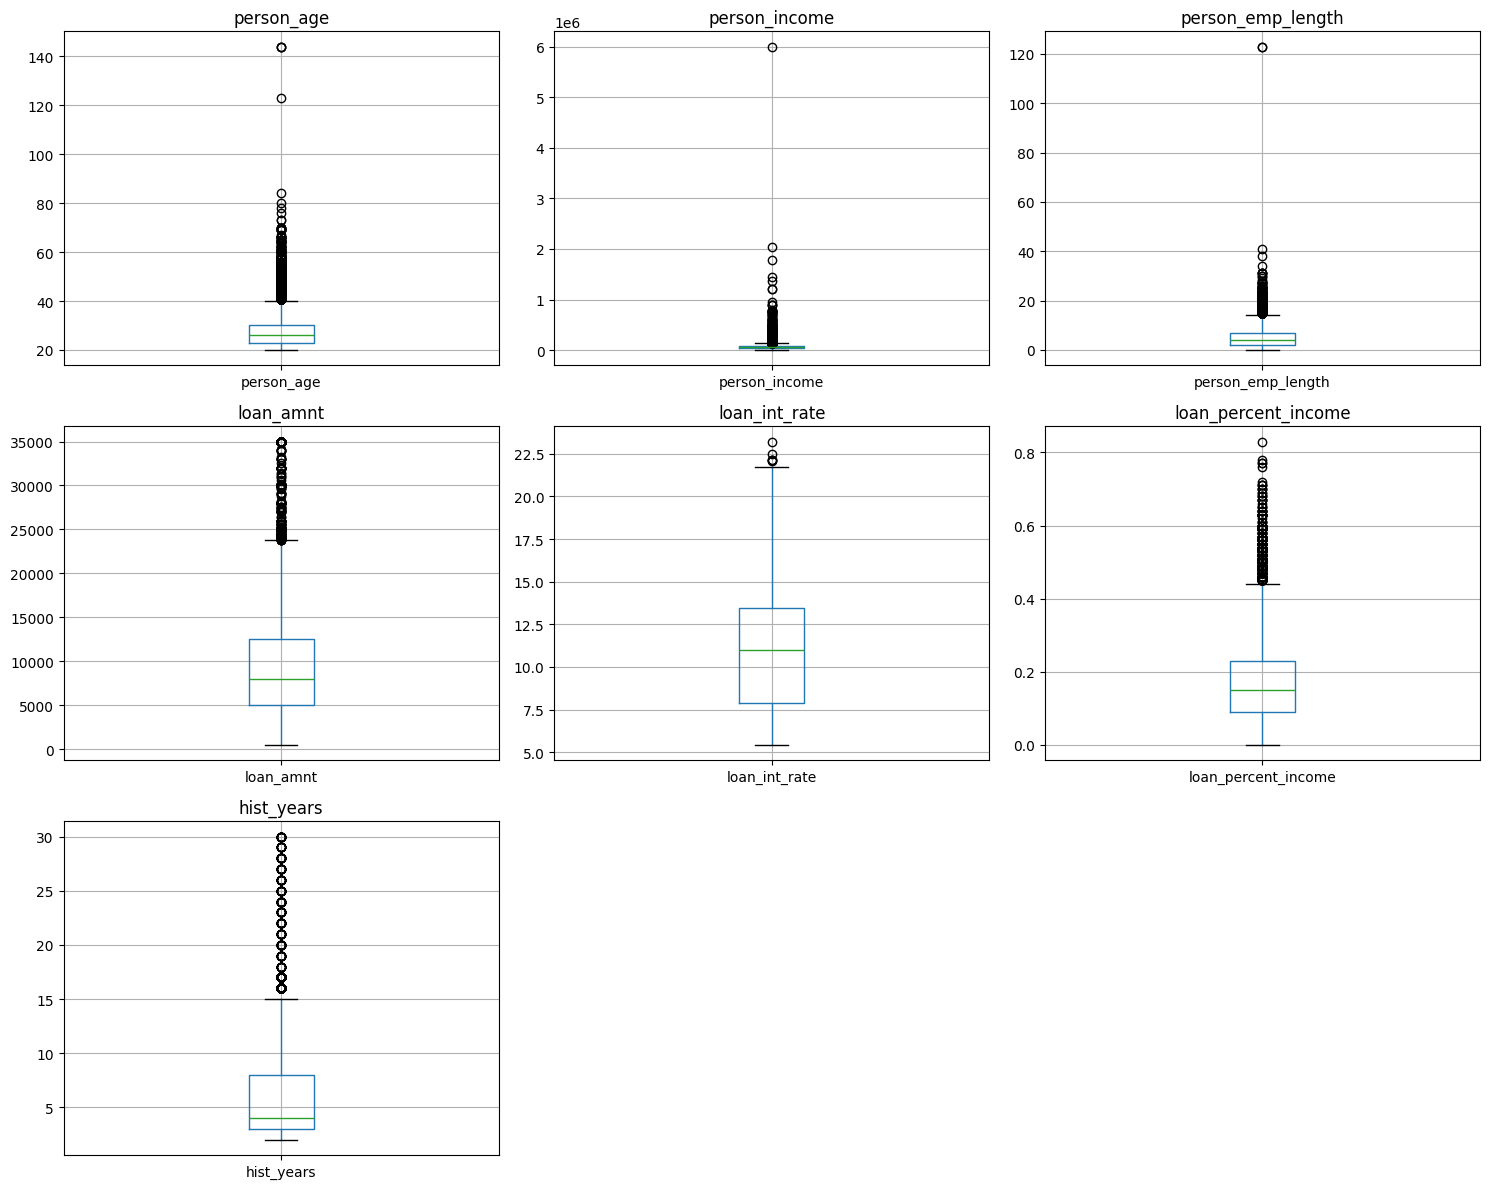

In [67]:
plot_cols = [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "hist_years"
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for ax, col in zip(axes.flatten(), plot_cols):
    data_cleaned.boxplot(column=col, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")

for ax in axes.flatten()[len(plot_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [68]:
print("Data to delete:")
print(f"Age > 100: {(data_cleaned['person_age'] > 100).sum()}")
print(f"Income > 2.5 mln: {(data_cleaned['person_income'] > 2500000).sum()}")
print(f"Employment length > 50: {(data_cleaned['person_emp_length'] > 50).sum()}")
print(f"Employment length > age - 15: {(data_cleaned['person_emp_length'] > data_cleaned['person_age'] - 15).sum()}")
print(f"Credit history > age - 15: {(data_cleaned['hist_years'] > data_cleaned['person_age'] - 15).sum()}")

mask = (
    (data_cleaned["person_age"] > 100) |
    (data_cleaned["person_income"] > 2500000) |
    (data_cleaned["person_emp_length"] > 50) |
    (data_cleaned["person_emp_length"] > data_cleaned["person_age"] - 15)
)

print(f"Observations to delete: {mask.sum()}")

data_cleaned = data_cleaned.loc[~mask].copy()

print(f"Cleaned df size (rows; columns): {data_cleaned.shape[0]}; {data_cleaned.shape[1]}")

Data to delete:
Age > 100: 4
Income > 2.5 mln: 1
Employment length > 50: 2
Employment length > age - 15: 2
Credit history > age - 15: 0
Observations to delete: 6
Cleaned df size (rows; columns): 28495; 12


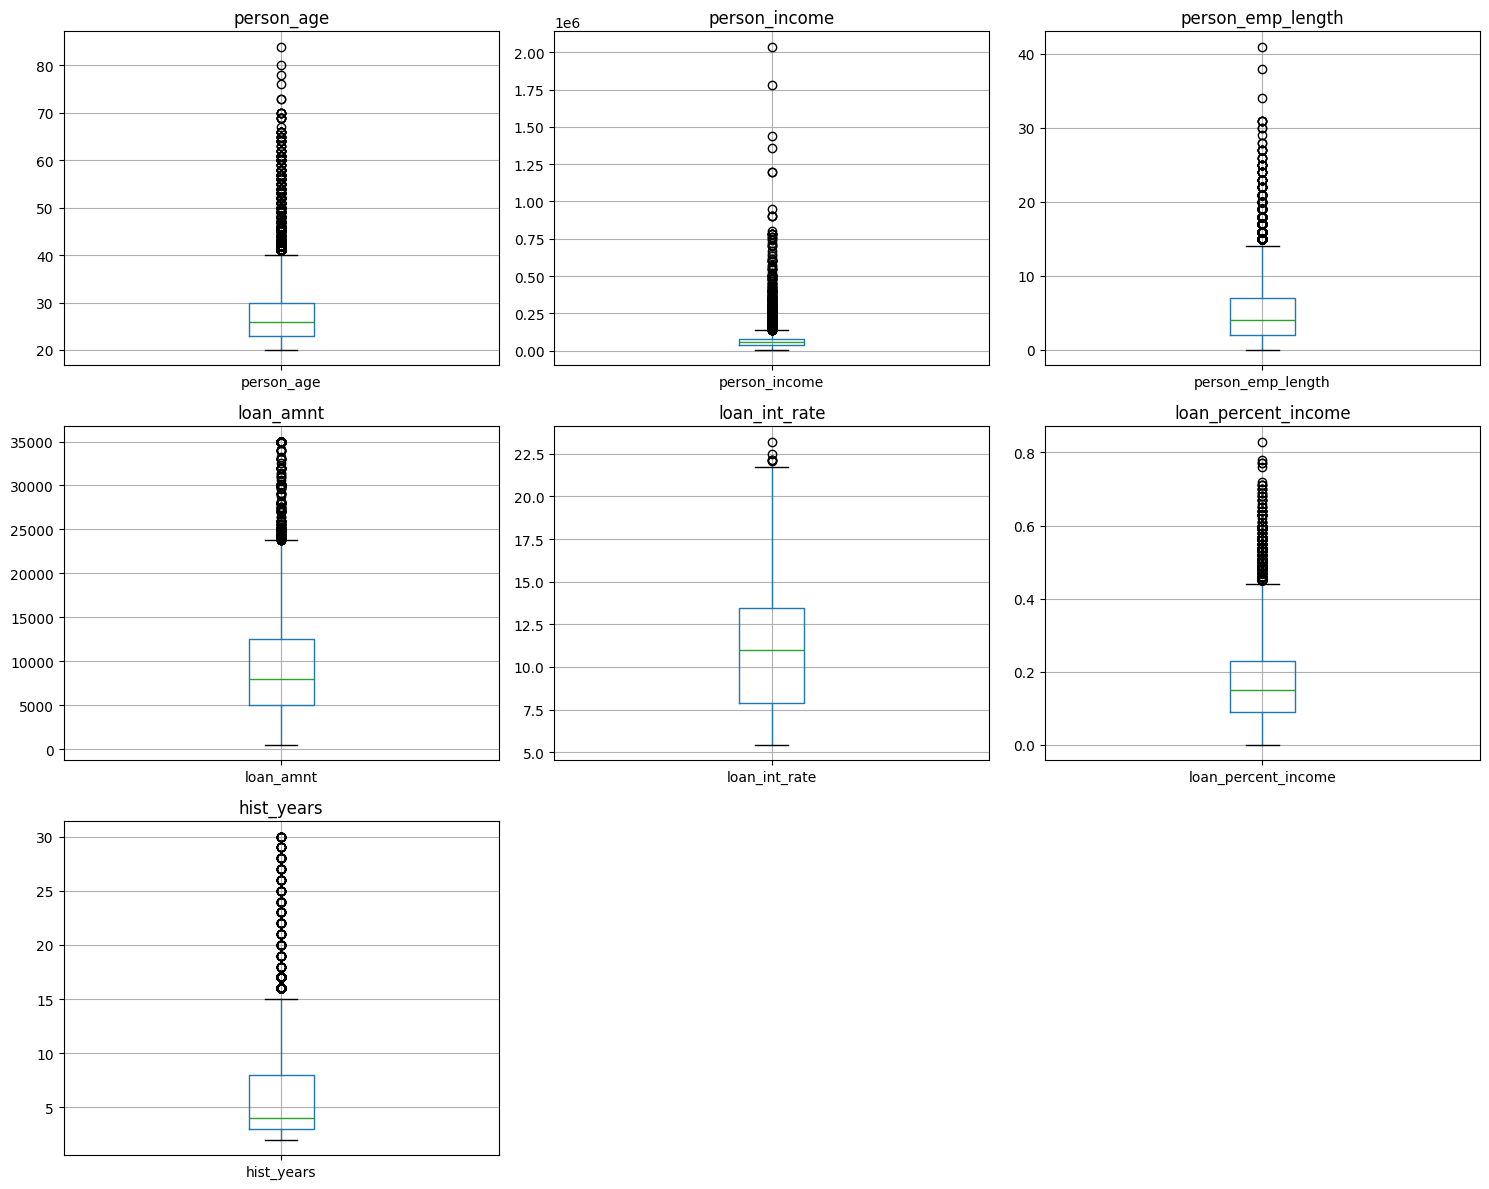

In [69]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for ax, col in zip(axes.flatten(), plot_cols):
    data_cleaned.boxplot(column=col, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")

for ax in axes.flatten()[len(plot_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

### EDA

In [70]:

def plot_structure_barplot(df, var, title_suffix, legend_title):
    s = df[var]

    counts = s.value_counts()
    pct = counts / counts.sum()

    labels = ((pct * 100).round(1).astype(str) + "% (" + counts.astype(int).astype(str) + ")")

    fig, ax = plt.subplots(figsize=(10, 8))
    fig.subplots_adjust(right=0.7)

    bottom = 0.0
    for (cat, frac), label in zip(pct.items(), labels):
        ax.bar([0], [frac], bottom=bottom, width=0.5, label=str(cat))
        ax.set_xlim(-0.5, 0.5)
        ax.text(
            0,
            bottom + frac / 2,
            label,
            ha="center",
            va="center",
            color="white",
            fontsize=12,
            fontweight="bold"
        )

        bottom += frac

    ax.set_title(f"Struktura wg {title_suffix}", fontsize=18, fontweight="bold")
    ax.set_ylabel("Udział", fontsize=13, fontweight="bold")
    ax.set_xticks([])

    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)

    plt.legend(title=legend_title,bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)

    plt.show()

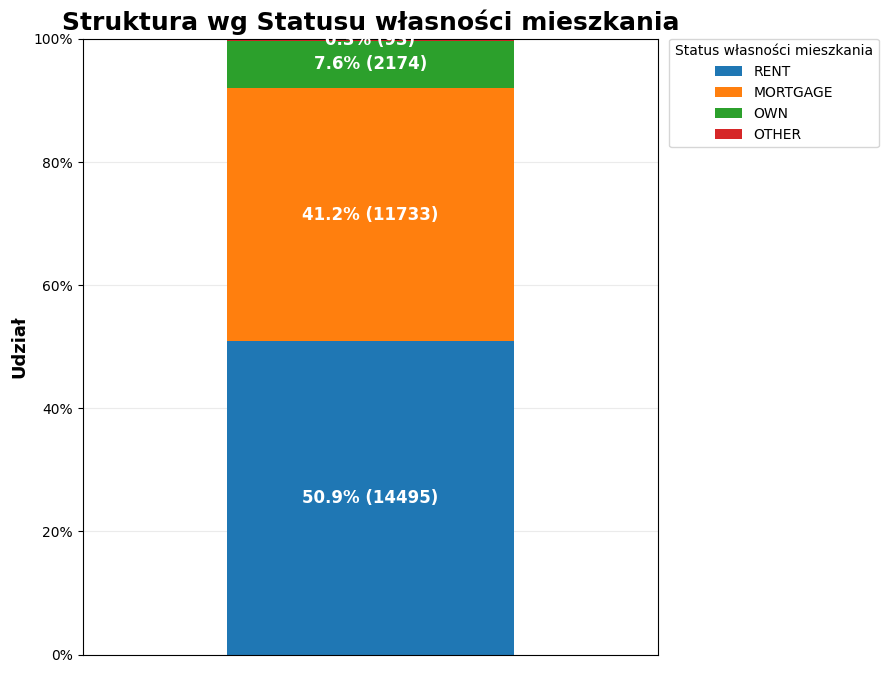

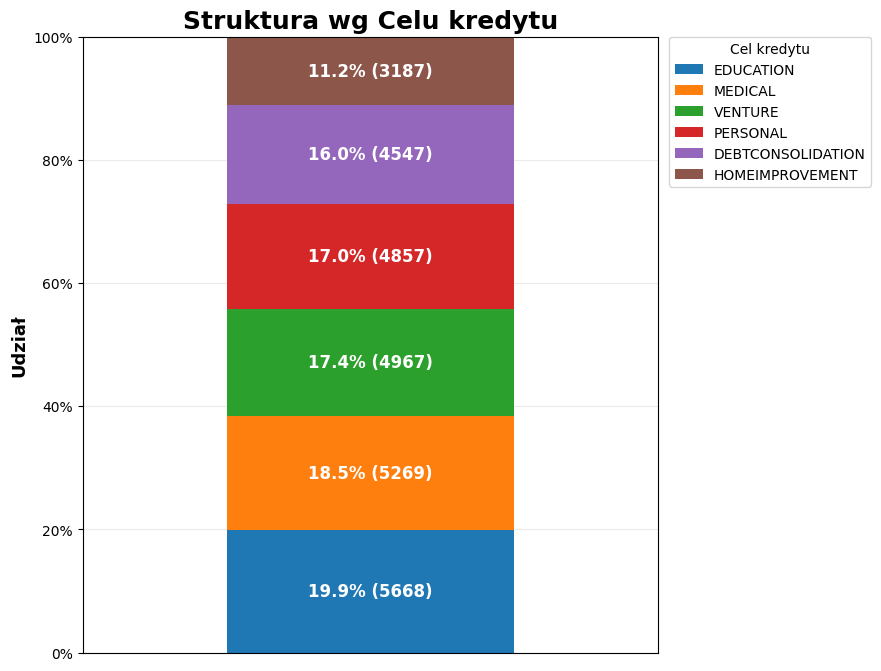

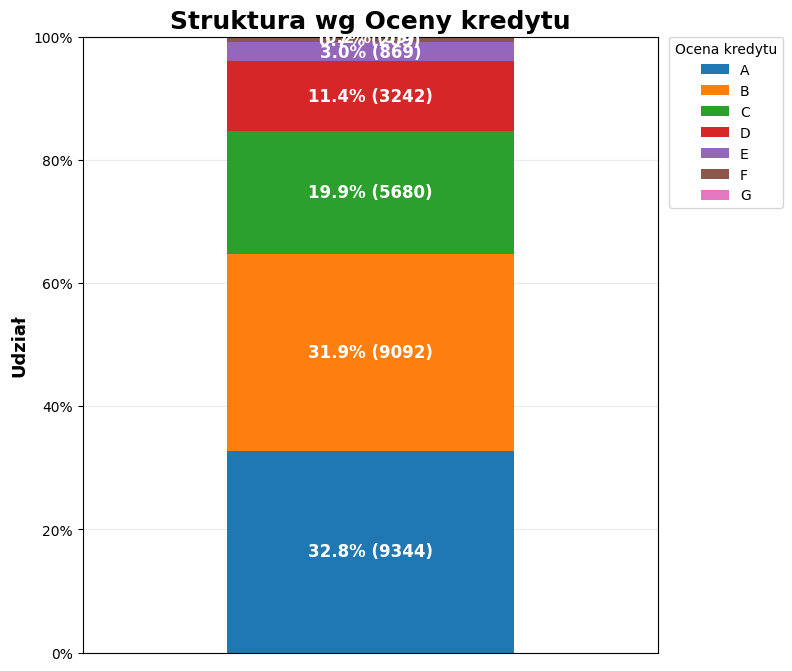

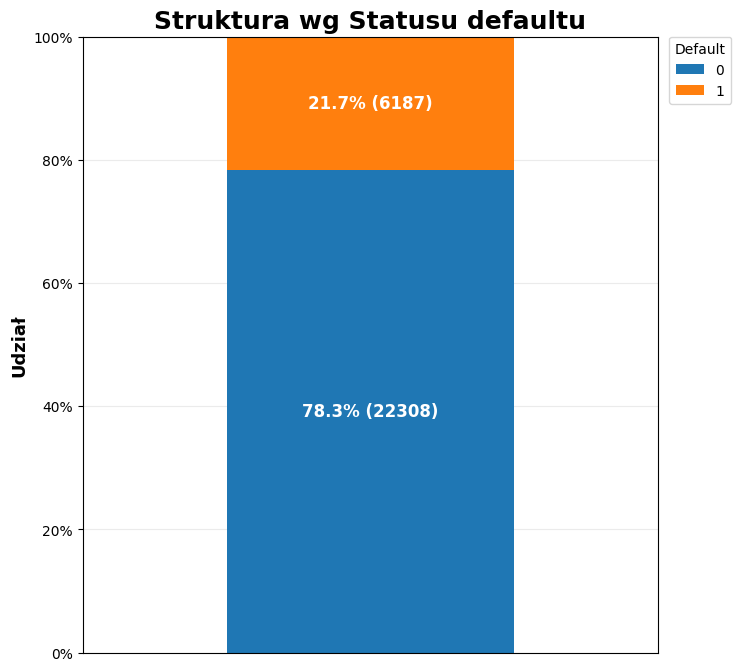

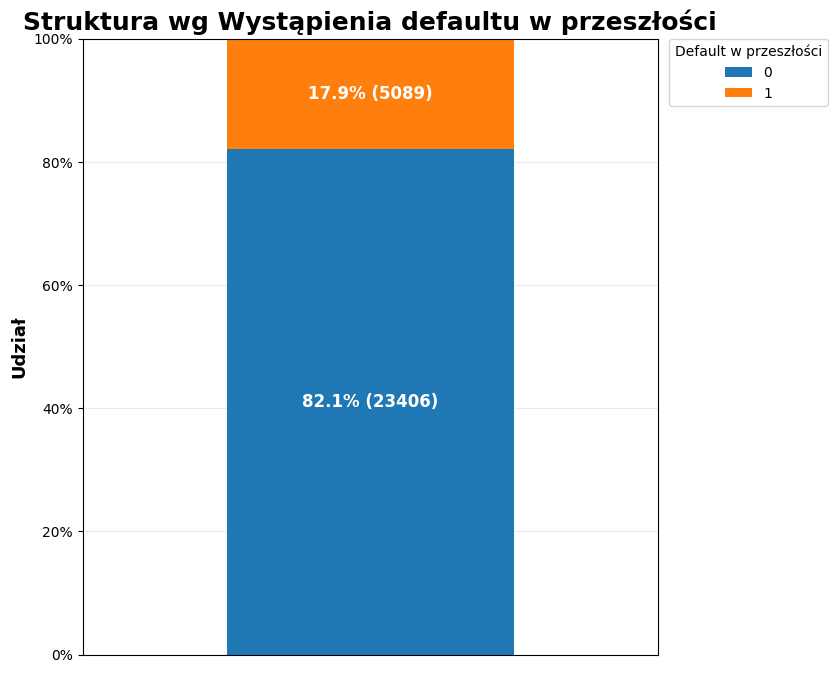

In [71]:
labels = {
    "person_home_ownership": ("Statusu własności mieszkania", "Status własności mieszkania"),
    "loan_intent": ("Celu kredytu", "Cel kredytu"),
    "loan_grade": ("Oceny kredytu", "Ocena kredytu"),
    "default": ("Statusu defaultu", "Default"),
    "hist_default_in_past": ("Wystąpienia defaultu w przeszłości", "Default w przeszłości")
}

cols_to_plot = list(
    data_cleaned.select_dtypes(include=["category"]).columns
) + [
    "default",
    "hist_default_in_past"
]

for col in cols_to_plot:
    plot_structure_barplot(
        data_cleaned,
        col,
        labels[col][0],
        labels[col][1]
    )

In [236]:
def plot_structure_histogram(df, var, title_suffix, bins=20):
    s = df[var].dropna()

    mean_val = s.mean()
    median_val = s.median()
    mode_val = s.mode().iloc[0]
    
    fig, ax = plt.subplots(figsize=(10, 8))

    ax.hist(
        s,
        bins=bins,
        edgecolor="black"
    )

    stats_text = (
        f"Średnia: {mean_val:.2f}\n"
        f"Mediana: {median_val:.2f}\n"
        f"Moda: {mode_val:.2f}"
        )

    ax.text(
        0.98,
        0.98,
        stats_text,
        transform=ax.transAxes,
        ha="right",
        va="top",
        bbox=dict(
            boxstyle="round",
            facecolor="white",
            alpha=0.8
            )
        )

    ax.set_title(
        f"Rozkład {title_suffix}",
        fontsize=18,
        fontweight="bold"
        )

    ax.set_xlabel(
        var,
        fontsize=13,
        fontweight="bold"
    )

    ax.set_ylabel(
        "Liczba obserwacji",
        fontsize=13,
        fontweight="bold"
    )

    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)

    plt.show()

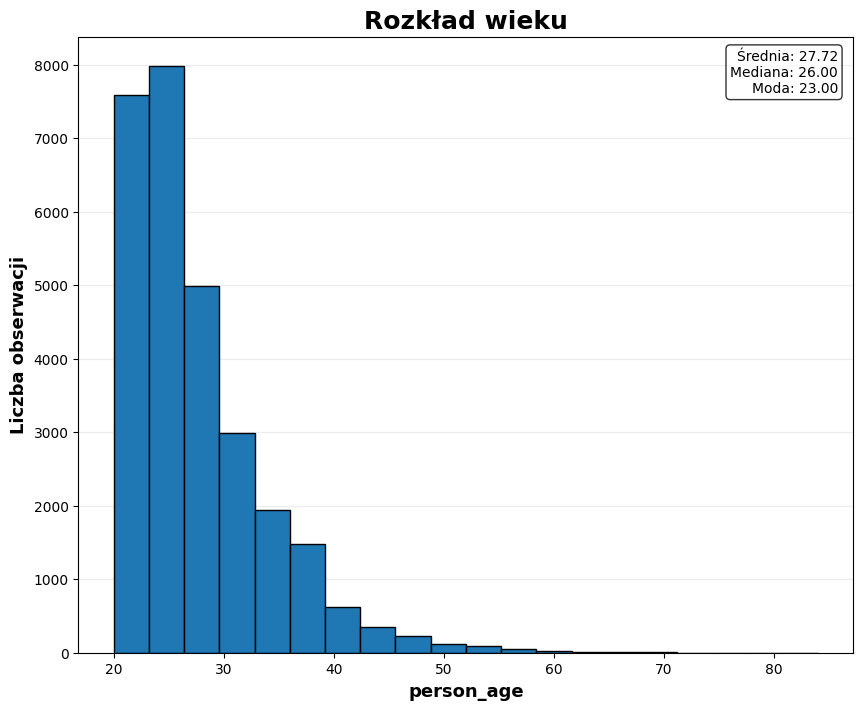

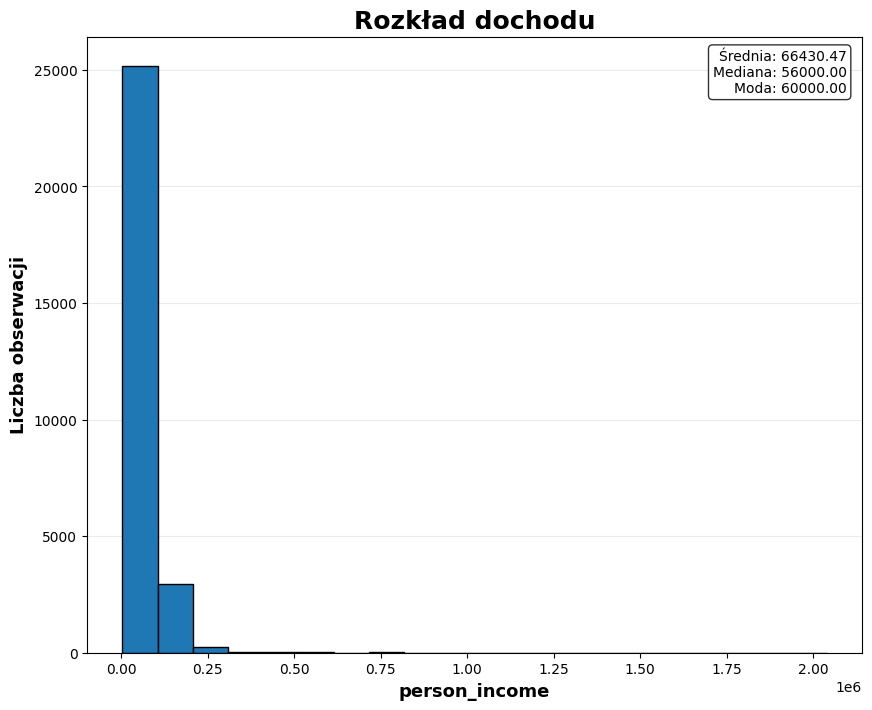

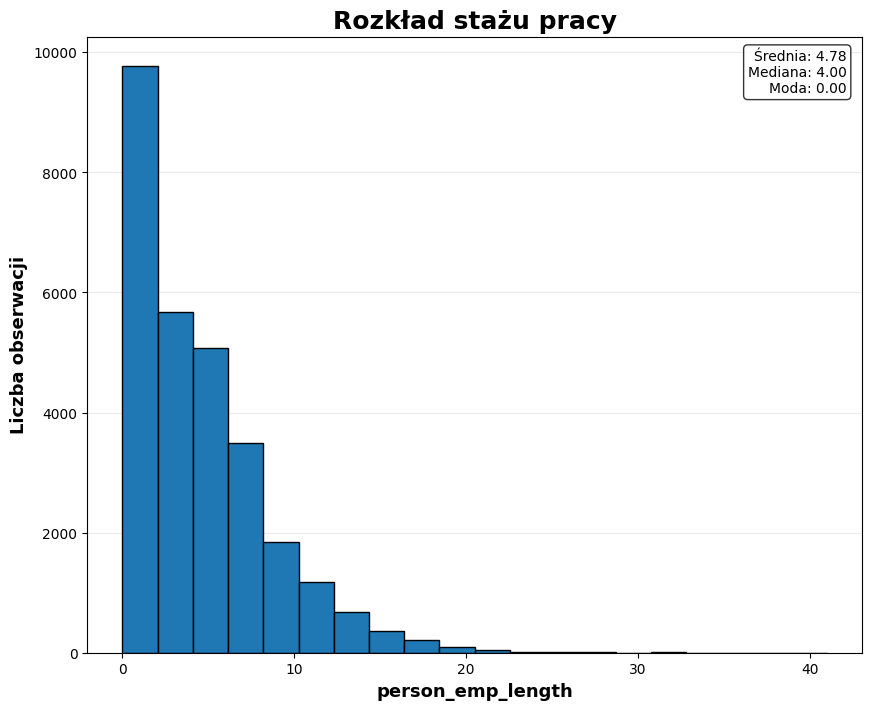

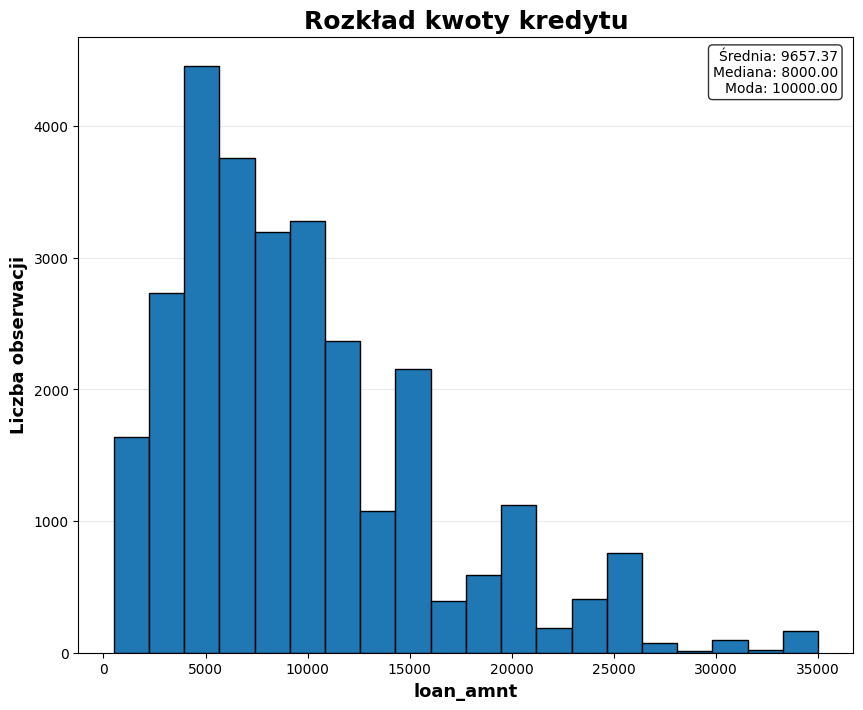

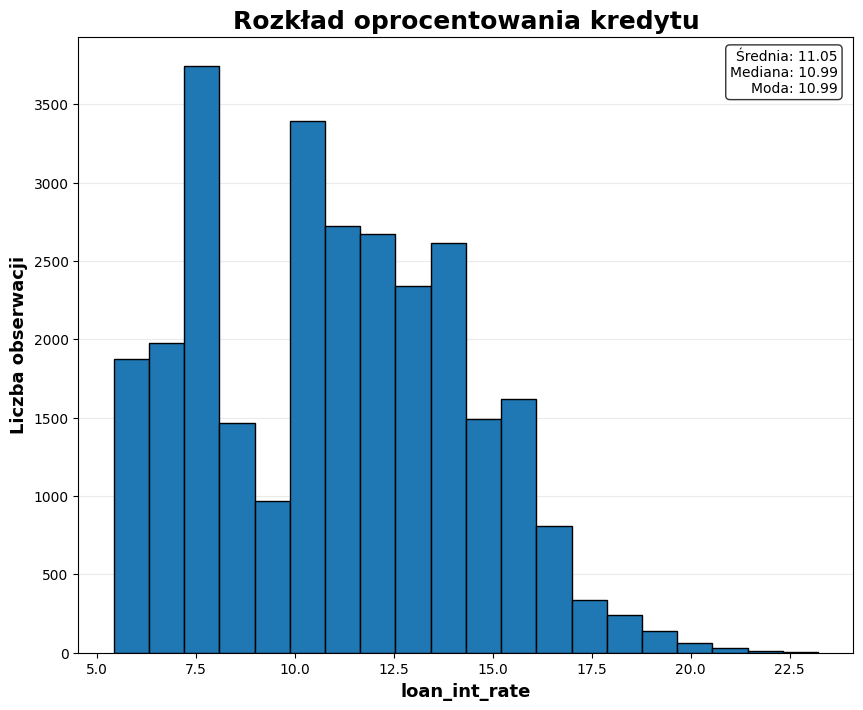

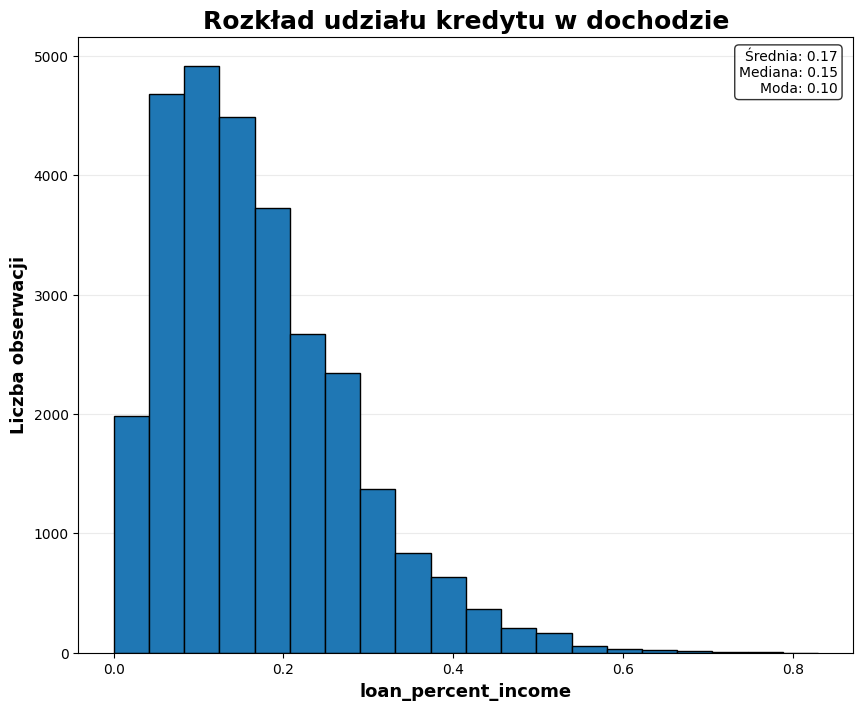

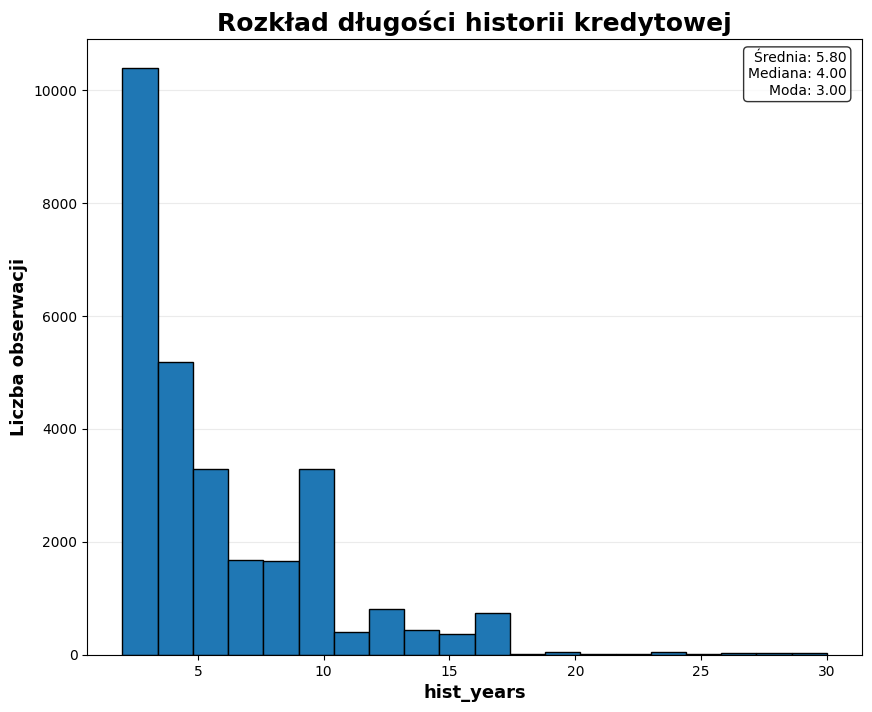

In [237]:
numeric_cols = [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "hist_years"
]

labels = {
    "person_age": "wieku",
    "person_income": "dochodu",
    "person_emp_length": "stażu pracy",
    "loan_amnt": "kwoty kredytu",
    "loan_int_rate": "oprocentowania kredytu",
    "loan_percent_income": "udziału kredytu w dochodzie",
    "hist_years": "długości historii kredytowej"
}

for col in numeric_cols:
    plot_structure_histogram(
        data_cleaned,
        col,
        labels[col]
    )

In [74]:
def plot_comparative_barplot(df, group_col, target_col, title, legend_title):

    cross_tab = pd.crosstab(df[group_col], df[target_col])
    pct_tab = cross_tab.div(cross_tab.sum(axis=1), axis=0)

    fig, ax = plt.subplots(figsize=(20, 8))
    fig.subplots_adjust(right=0.75)

    indices = np.arange(len(cross_tab))
    width = 0.6
    bottoms = np.zeros(len(cross_tab))

    for col_name in cross_tab.columns:
        proportions = pct_tab[col_name].to_numpy()
        counts = cross_tab[col_name].to_numpy()

        bars = ax.bar(
            indices,
            proportions,
            bottom=bottoms,
            width=width,
            label=str(col_name)
        )

        for idx, rect in enumerate(bars):
            height = rect.get_height()

            if height > 0.02:
                label_text = f"{height * 100:.1f}%\n({int(counts[idx])})"

                ax.text(
                    rect.get_x() + rect.get_width() / 2,
                    bottoms[idx] + height / 2,
                    label_text,
                    ha="center",
                    va="center",
                    color="white",
                    fontsize=11,
                    fontweight="bold"
                )

        bottoms += proportions

    ax.set_title(title, fontsize=18, fontweight="bold", pad=20)
    ax.set_ylabel("Udział obserwacji", fontsize=13, fontweight="bold")
    ax.set_xticks(indices)
    ax.set_xticklabels(cross_tab.index, fontsize=8, fontweight="bold")
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)

    plt.legend(title=legend_title, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.show()

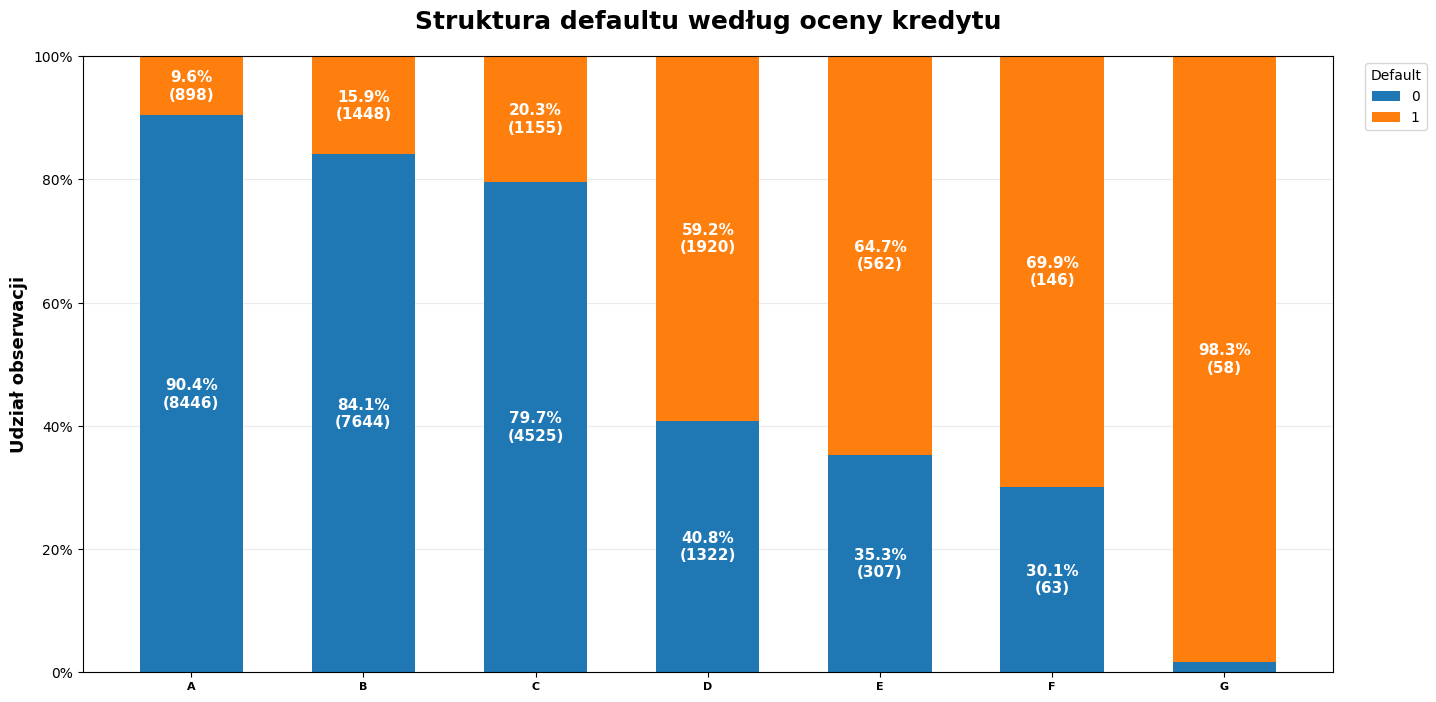

In [75]:
plot_comparative_barplot(
    data_cleaned,
    "loan_grade",
    "default",
    "Struktura defaultu według oceny kredytu",
    "Default"
)

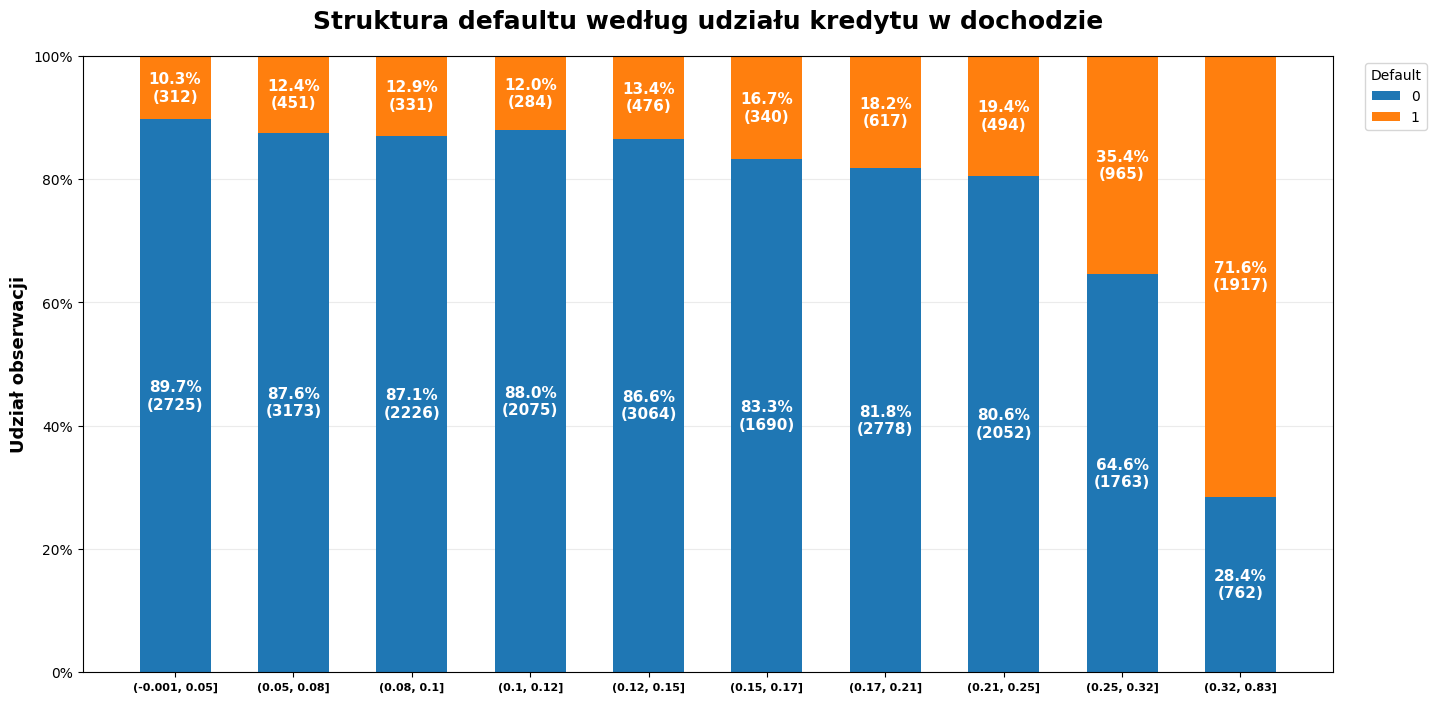

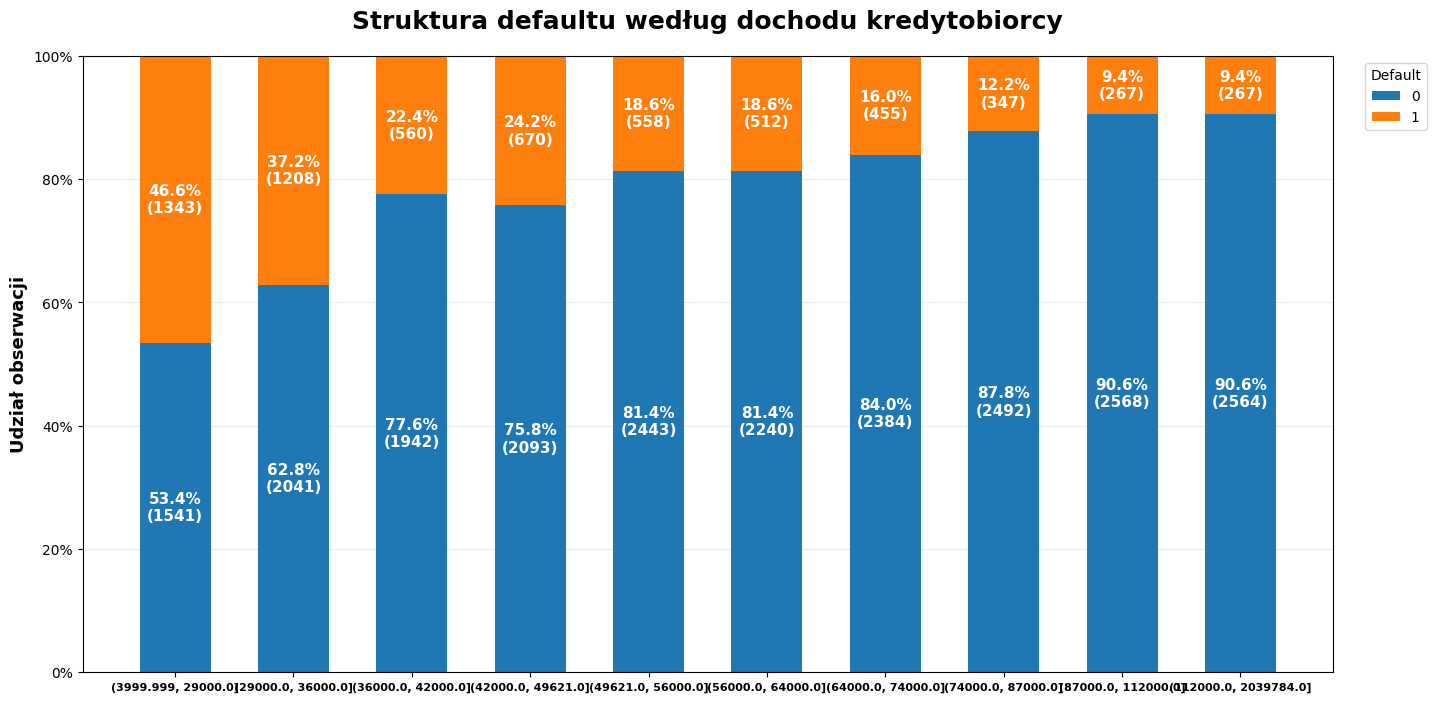

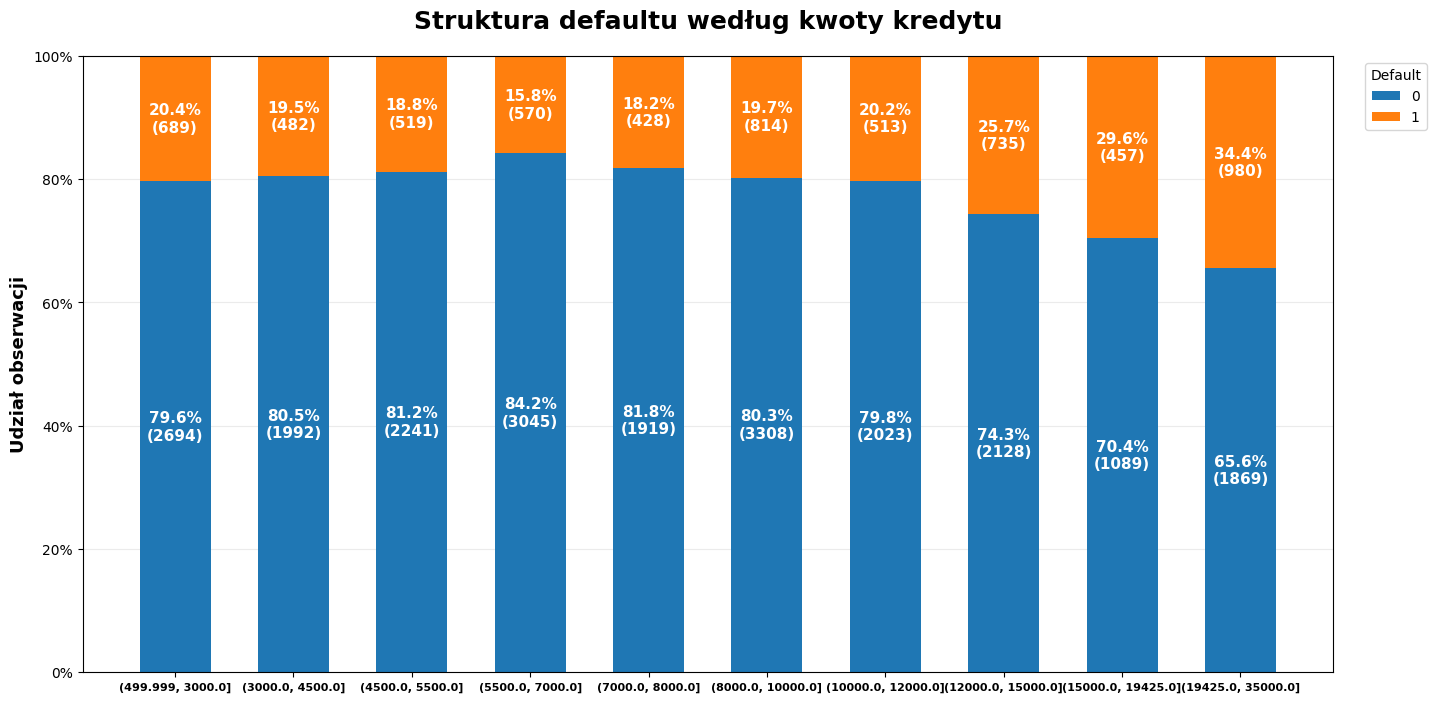

In [76]:
data_plots = data_cleaned.copy()
data_plots["loan_percent_income_bin"] = pd.qcut(
    data_plots["loan_percent_income"],
    q=10
)

data_plots["person_income_bin"] = pd.qcut(
    data_plots["person_income"],
    q=10
)

data_plots["loan_amnt_bin"] = pd.qcut(
    data_plots["loan_amnt"],
    q=10
)


plot_comparative_barplot(
    data_plots,
    "loan_percent_income_bin",
    target,
    "Struktura defaultu według udziału kredytu w dochodzie",
    "Default"
)

plot_comparative_barplot(
    data_plots,
    "person_income_bin",
    target,
    "Struktura defaultu według dochodu kredytobiorcy",
    "Default"
)

plot_comparative_barplot(
    data_plots,
    "loan_amnt_bin",
    target,
    "Struktura defaultu według kwoty kredytu",
    "Default"
)

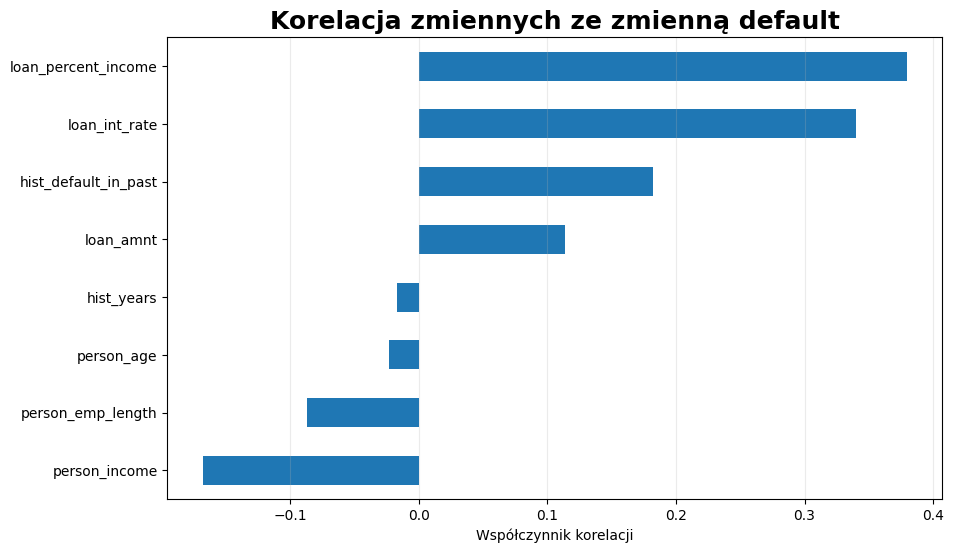

In [241]:
corr_target = (
    data_cleaned
    .select_dtypes(include=["number"])
    .corr()[target]
    .drop(target)
    .sort_values()
)

plt.figure(figsize=(10, 6))

corr_target.plot(kind="barh")

plt.title(
    f"Korelacja zmiennych ze zmienną {target}",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Współczynnik korelacji")
plt.ylabel("")

plt.grid(axis="x", alpha=0.25)
plt.show()

### EVALUATION METRICS

In [218]:
def lift_gain_at_percent(y_true,
                         y_proba,
                         percent):
    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)

    n_selected = int(np.ceil(len(y_true) * percent))
    order = np.argsort(y_proba)[::-1]
    selected = order[:n_selected]

    total_events = y_true.sum()
    events_selected = y_true[selected].sum()

    gain = events_selected / total_events if total_events > 0 else np.nan
    lift = gain / percent if percent > 0 else np.nan

    return lift, gain


def evaluate_model(
        model,
        X,
        y_true,
        label_encoder,
        selected_percent,
        model_name,
        verbose):

    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]


    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    cm = np.array([
        [tp, fn],
        [fp, tn]
        ])
    
    labels = label_encoder.classes_
    cm_named = pd.DataFrame(
        cm,
        index=[f"Actual: {labels[1]}", f"Actual: {labels[0]}"],
        columns=[f"Predicted: {labels[1]}", f"Predicted: {labels[0]}"]
    )

    accuracy = (tp + tn) / (tp + tn + fp + fn)
    mer = 1 - accuracy

    recall = tp / (tp + fn)
    specificity = tn / (tn + fp)
    precision = tp / (tp + fp)
    npv = tn / (tn + fn)

    fpr = fp / (fp + tn)
    fnr = fn / (fn + tp)
    fdr = fp / (fp + tp)

    f1 = 2 * precision * recall / (precision + recall)

    youden = recall + specificity - 1
    gmean = np.sqrt(recall * specificity)


    fpr_curve, tpr_curve, thresholds = roc_curve(y_true, y_proba)
    auc = roc_auc_score(y_true, y_proba)

    lift_percent, gain_percent = lift_gain_at_percent(y_true=y_true, y_proba=y_proba, percent=selected_percent)

    metrics = {
        "Accuracy": accuracy,
        "MER": mer,
        "Recall (TPR)": recall,
        "Specificity (TNR)": specificity,
        "Precision (PPV)": precision,
        "NPV": npv,
        "FPR": fpr,
        "FDR": fdr,
        "FNR": fnr,
        "F1 score": f1,
        "Youden Index": youden,
        "Geometric mean": gmean,
        "Lift": lift_percent,
        "Gain": gain_percent,
        "AUC": auc,
        "TP": tp,
        "FP": fp,
        "TN": tn,
        "FN": fn
    }

    if verbose:
        print(f"\n--- {model_name} evaluation ---")
        print("\nConfusion matrix:")
        print(cm_named)
        print("\nMetrics:")
        for k, v in metrics.items():
            if isinstance(v, float):
                print(f"{k:20s}: {v:.4f}")
            else:
                print(f"{k:20s}: {v}")

    return {
       "model_name": model_name,
        "metrics": metrics,
        "roc": {
            "fpr": fpr_curve,
            "tpr": tpr_curve,
            "thresholds": thresholds
        },
        "y_pred": y_pred,
        "y_proba": y_proba
    }

In [78]:
def get_feature_importance(
    model,
    feature_names,
    top_n=None
):
    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": model.feature_importances_
    }).sort_values(
        "importance",
        ascending=False
    )

    if top_n is not None:
        importance_df = importance_df.head(top_n)

    return importance_df.reset_index(drop=True)

In [79]:
def plot_roc(evaluation):
    model_name = evaluation["model_name"]
    roc_data = evaluation["roc"]
    auc = evaluation["metrics"]["AUC"]

    plt.figure(figsize=(8, 6))

    plt.plot(
        roc_data["fpr"],
        roc_data["tpr"],
        linewidth=2,
        label=f"{model_name} (AUC = {auc:.4f})"
    )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Klasyfikator losowy"
    )

    plt.xlabel(
        "FPR"
    )
    plt.ylabel(
        "TPR"
    )
    plt.title(f"Krzywa ROC - {model_name}")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [80]:
def compare_models(evaluations):

    rows = []

    for model_eval in evaluations:

        metrics = model_eval["metrics"]

        rows.append({
            "Model": model_eval["model_name"],
            "Accuracy": metrics["Accuracy"],
            "MER": metrics["MER"],
            "Recall": metrics["Recall (TPR)"],
            "Specificity": metrics["Specificity (TNR)"],
            "Precision": metrics["Precision (PPV)"],
            "F1": metrics["F1 score"],
            "AUC": metrics["AUC"],
            "Lift": metrics["Lift"],
            "Gain": metrics["Gain"]
        })

    return pd.DataFrame(rows)

In [81]:
def plot_roc_comparison(evaluations):

    plt.figure(figsize=(8, 6))

    for evaluation in evaluations:

        model_name = evaluation["model_name"]
        roc_data = evaluation["roc"]
        auc = evaluation["metrics"]["AUC"]

        plt.plot(
            roc_data["fpr"],
            roc_data["tpr"],
            linewidth=2,
            label=f"{model_name} (AUC = {auc:.4f})"
        )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Klasyfikator losowy"
    )

    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title("Porównanie krzywych ROC")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

### LOGISTIC REGRESSION

In [223]:
X = data_cleaned.drop(columns=[target])
y = data_cleaned[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=test_size, 
    random_state=seed,
    stratify=y
)

categorical_features = ["person_home_ownership", "loan_intent", "loan_grade"]
numeric_features = [col for col in X.columns if col not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="error"), categorical_features)
    ]
)

X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)


print(f"Training observations: {X_train_transformed.shape[0]}")
print(f"Test observations: {X_test_transformed.shape[0]}")
print(f"Number of predictors after encoding: {X_train_transformed.shape[1]}")

Training observations: 19946
Test observations: 8549
Number of predictors after encoding: 22


In [203]:
lr_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("lr", LogisticRegression(
            max_iter=2000,           
            class_weight="balanced", 
            random_state=seed,
            solver="saga",
            penalty="elasticnet",
            l1_ratio=0.5     
        ))
    ]
)

lr_param_grid = {
    "lr__C": [0.01, 0.1, 1.0, 10.0, 100.0],
    "lr__l1_ratio": [0.0, 1.0] 
}

lr_grid_search = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=lr_param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=n_jobs,
    verbose=verbose,
    return_train_score=True
)

lr_grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


c:\Users\janwz\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...ver='saga'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'lr__C': [0.01, 0.1, ...], 'lr__l1_ratio': [0.0, 1.0]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-4
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_`

In [205]:
lr_best = lr_grid_search.best_estimator_

print(f"Best model parameters: {lr_grid_search.best_params_}")
print(f"Best cross-validation AUC: {lr_grid_search.best_score_:.4f}")

Best model parameters: {'lr__C': 1.0, 'lr__l1_ratio': 1.0}
Best cross-validation AUC: 0.8732


In [224]:
label_encoder = LabelEncoder()
label_encoder.fit(y_train)

lr_best_train_eval = evaluate_model(
    model=lr_best,
    X=X_train,
    y_true=y_train,
    label_encoder=label_encoder,
    selected_percent=0.1,
    model_name="Best LR - Train",
    verbose=verbose
)


--- Best LR - Train evaluation ---

Confusion matrix:
           Predicted: 1  Predicted: 0
Actual: 1          3371           960
Actual: 0          2785         12830

Metrics:
Accuracy            : 0.8122
MER                 : 0.1878
Recall (TPR)        : 0.7783
Specificity (TNR)   : 0.8216
Precision (PPV)     : 0.5476
NPV                 : 0.9304
FPR                 : 0.1784
FDR                 : 0.4524
FNR                 : 0.2217
F1 score            : 0.6429
Youden Index        : 0.6000
Geometric mean      : 0.7997
Lift                : 3.8351
Gain                : 0.3835
AUC                 : 0.8744
TP                  : 3371
FP                  : 2785
TN                  : 12830
FN                  : 960


In [225]:
lr_best_test_eval = evaluate_model(
    model=lr_best,
    X=X_test,
    y_true=y_test,
    label_encoder=label_encoder,
    selected_percent=0.1,
    model_name="Best LR - Test",
    verbose=verbose
)


--- Best LR - Test evaluation ---

Confusion matrix:
           Predicted: 1  Predicted: 0
Actual: 1          1445           411
Actual: 0          1160          5533

Metrics:
Accuracy            : 0.8162
MER                 : 0.1838
Recall (TPR)        : 0.7786
Specificity (TNR)   : 0.8267
Precision (PPV)     : 0.5547
NPV                 : 0.9309
FPR                 : 0.1733
FDR                 : 0.4453
FNR                 : 0.2214
F1 score            : 0.6478
Youden Index        : 0.6052
Geometric mean      : 0.8023
Lift                : 3.7446
Gain                : 0.3745
AUC                 : 0.8711
TP                  : 1445
FP                  : 1160
TN                  : 5533
FN                  : 411


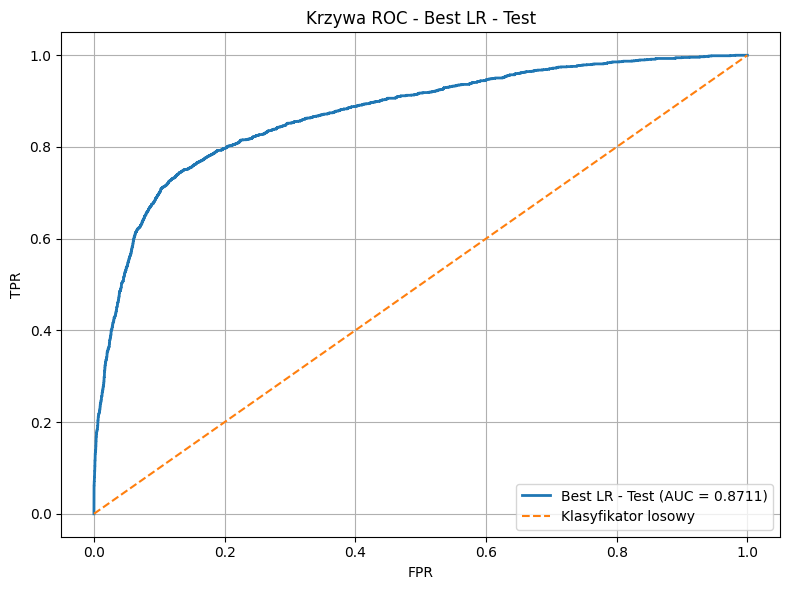

In [130]:
plot_roc(lr_best_test_eval)

                        Feature  Beta Coefficient  Odds Ratio (Iloraz Szans)
0                  loan_grade_G            4.0070                    54.9836
1                  loan_grade_F            2.1957                     8.9864
2                  loan_grade_E            2.0037                     7.4164
3                  loan_grade_D            1.8801                     6.5543
4           loan_percent_income            1.3560                     3.8806
5    person_home_ownership_RENT            0.6415                     1.8993
6                 loan_int_rate            0.5023                     1.6525
7   person_home_ownership_OTHER            0.4176                     1.5183
8   loan_intent_HOMEIMPROVEMENT            0.1545                     1.1670
9                    hist_years            0.0738                     1.0765
10                person_income            0.0384                     1.0391
11                 loan_grade_C            0.0157                     1.0158

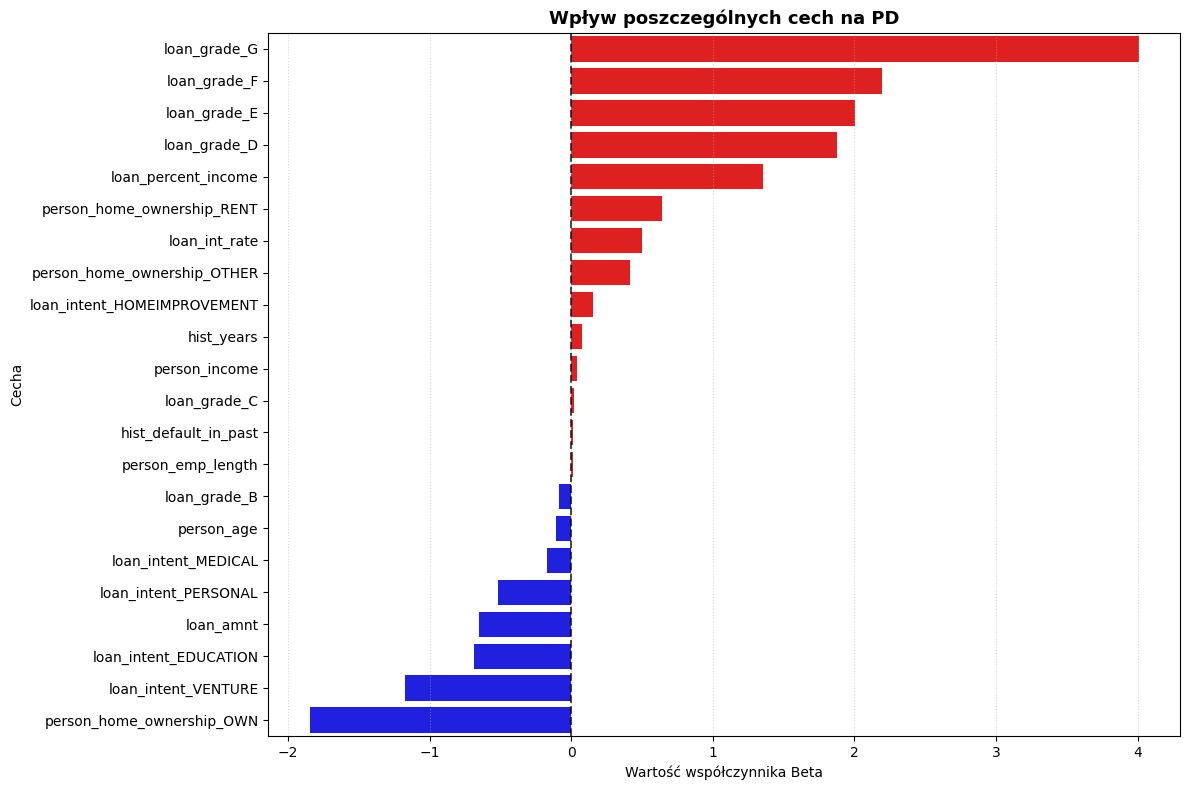

In [132]:
feature_names_lr = lr_best.named_steps["preprocessor"].get_feature_names_out()
feature_names_lr = [name.replace("num__", "").replace("cat__", "") for name in feature_names_lr]

coefficients_lr = lr_best.named_steps["lr"].coef_[0]

lr_importance_df = pd.DataFrame({
    "Feature": feature_names_lr,
    "Beta Coefficient": coefficients_lr,
    "Odds Ratio (Iloraz Szans)": np.exp(coefficients_lr)
}).sort_values(by="Beta Coefficient", ascending=False).reset_index(drop=True)

print(lr_importance_df.round(4).to_string())

plt.figure(figsize=(12, 8))

colors = ['red' if x > 0 else 'blue' for x in lr_importance_df['Beta Coefficient']]

sns.barplot(x='Beta Coefficient', y='Feature', data=lr_importance_df, hue='Feature', palette=colors)
plt.title('Wpływ poszczególnych cech na PD', fontsize=13, fontweight='bold')
plt.xlabel('Wartość współczynnika Beta')
plt.ylabel('Cecha')
plt.axvline(x=0, color='black', linestyle='--', alpha=0.7)
plt.grid(True, axis='x', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

### DATA FOR MODELS

In [207]:
X = data_cleaned.drop(columns=[target])
y = data_cleaned[target]

# Encoding categorical predictors
X_encoded = pd.get_dummies(X, drop_first=True)

# Encoding target
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)


# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_encoded,
    test_size=test_size,
    random_state=seed,
    stratify=y_encoded
)

feature_names = X_encoded.columns.tolist()

print(f"Training observations: {X_train.shape[0]}")
print(f"Test observations: {X_test.shape[0]}")
print(f"Number of predictors after encoding: {X_train.shape[1]}")

Training observations: 19946
Test observations: 8549
Number of predictors after encoding: 22


### DECISION TREE

In [83]:
baseline_tree = DecisionTreeClassifier(random_state=seed)

baseline_tree.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [84]:
baseline_tree_train_eval = evaluate_model(
    model=baseline_tree,
    X=X_train,
    y_true=y_train,
    label_encoder=label_encoder,
    selected_percent = 0.1,
    model_name="Baseline Decision Tree - Train",
    verbose=1
)

baseline_tree_test_eval = evaluate_model(
    model=baseline_tree,
    X=X_test,
    y_true=y_test,
    label_encoder=label_encoder,
    selected_percent = 0.1,
    model_name="Baseline Decision Tree - Test",
    verbose=1
)


--- Baseline Decision Tree - Train evaluation ---

Confusion matrix:
           Predicted: 1  Predicted: 0
Actual: 1          4331             0
Actual: 0             0         15615

Metrics:
Accuracy            : 1.0000
MER                 : 0.0000
Recall (TPR)        : 1.0000
Specificity (TNR)   : 1.0000
Precision (PPV)     : 1.0000
NPV                 : 1.0000
FPR                 : 0.0000
FDR                 : 0.0000
FNR                 : 0.0000
F1 score            : 1.0000
Youden Index        : 1.0000
Geometric mean      : 1.0000
Lift                : 4.6063
Gain                : 0.4606
AUC                 : 1.0000
TP                  : 4331
FP                  : 0
TN                  : 15615
FN                  : 0

--- Baseline Decision Tree - Test evaluation ---

Confusion matrix:
           Predicted: 1  Predicted: 0
Actual: 1          1451           405
Actual: 0           502          6191

Metrics:
Accuracy            : 0.8939
MER                 : 0.1061
Recall (TPR)     

In [85]:
print(f"Tree depth: {baseline_tree.get_depth()}")
print(f"Number of leaves: {baseline_tree.get_n_leaves()}")

Tree depth: 32
Number of leaves: 1778


In [86]:
pruning_path = baseline_tree.cost_complexity_pruning_path(
    X_train,
    y_train
)

ccp_alphas = pruning_path.ccp_alphas

ccp_alphas = np.unique(ccp_alphas[:-1])

print(f"Number of tested ccp_alpha values: {len(ccp_alphas)}")

Number of tested ccp_alpha values: 433


In [109]:
tree_grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(
        random_state=seed
    ),
    param_grid={
        "ccp_alpha": ccp_alphas
    },
    scoring="roc_auc",
    cv=5,
    n_jobs=n_jobs,
    return_train_score=True
)

tree_grid_search.fit(
    X_train,
    y_train
)

best_ccp_alpha = tree_grid_search.best_params_["ccp_alpha"]

print(f"Best ccp_alpha: {best_ccp_alpha:.6f}")
print(f"Best cross-validation AUC: {tree_grid_search.best_score_:.4f}")

Best ccp_alpha: 0.000208
Best cross-validation AUC: 0.9058


In [88]:
decision_tree = tree_grid_search.best_estimator_

decision_tree_train_eval = evaluate_model(
    model=decision_tree,
    X=X_train,
    y_true=y_train,
    label_encoder=label_encoder,
    selected_percent = 0.1,
    model_name="Pruned Decision Tree - Train",
    verbose=1
)


--- Pruned Decision Tree - Train evaluation ---

Confusion matrix:
           Predicted: 1  Predicted: 0
Actual: 1          3095          1236
Actual: 0            95         15520

Metrics:
Accuracy            : 0.9333
MER                 : 0.0667
Recall (TPR)        : 0.7146
Specificity (TNR)   : 0.9939
Precision (PPV)     : 0.9702
NPV                 : 0.9262
FPR                 : 0.0061
FDR                 : 0.0298
FNR                 : 0.2854
F1 score            : 0.8230
Youden Index        : 0.7085
Geometric mean      : 0.8428
Lift                : 4.6063
Gain                : 0.4606
AUC                 : 0.9114
TP                  : 3095
FP                  : 95
TN                  : 15520
FN                  : 1236


In [221]:
decision_tree_test_eval = evaluate_model(
    model=decision_tree,
    X=X_test,
    y_true=y_test,
    label_encoder=label_encoder,
    selected_percent = 0.1,
    model_name="Pruned Decision Tree - Test",
    verbose=1
)


--- Pruned Decision Tree - Test evaluation ---

Confusion matrix:
           Predicted: 1  Predicted: 0
Actual: 1          1326           530
Actual: 0            84          6609

Metrics:
Accuracy            : 0.9282
MER                 : 0.0718
Recall (TPR)        : 0.7144
Specificity (TNR)   : 0.9874
Precision (PPV)     : 0.9404
NPV                 : 0.9258
FPR                 : 0.0126
FDR                 : 0.0596
FNR                 : 0.2856
F1 score            : 0.8120
Youden Index        : 0.7019
Geometric mean      : 0.8399
Lift                : 4.5905
Gain                : 0.4591
AUC                 : 0.9063
TP                  : 1326
FP                  : 84
TN                  : 6609
FN                  : 530


In [ ]:
tree_comparison = pd.DataFrame([
    {
        "Model": "Baseline Decision Tree",
        "Train Accuracy": baseline_tree_train_eval["metrics"]["Accuracy"],
        "Test Accuracy": baseline_tree_test_eval["metrics"]["Accuracy"],
        "Train AUC": baseline_tree_train_eval["metrics"]["AUC"],
        "Test AUC": baseline_tree_test_eval["metrics"]["AUC"],
        "Train Lift": baseline_tree_train_eval["metrics"]["Lift"],
        "Test Lift": baseline_tree_test_eval["metrics"]["Lift"],
        "Train Gain": baseline_tree_train_eval["metrics"]["Gain"],
        "Test Gain": baseline_tree_test_eval["metrics"]["Gain"],
        "Depth": baseline_tree.get_depth(),
        "Leaves": baseline_tree.get_n_leaves(),
        "ccp_alpha": 0
    },
    {
        "Model": "Pruned Decision Tree",
        "Train Accuracy": decision_tree_train_eval["metrics"]["Accuracy"],
        "Test Accuracy": decision_tree_test_eval["metrics"]["Accuracy"],
        "Train AUC": decision_tree_train_eval["metrics"]["AUC"],
        "Test AUC": decision_tree_test_eval["metrics"]["AUC"],
        "Train Lift": decision_tree_train_eval["metrics"]["Lift"],
        "Test Lift": decision_tree_test_eval["metrics"]["Lift"],
        "Train Gain": decision_tree_train_eval["metrics"]["Gain"],
        "Test Gain": decision_tree_test_eval["metrics"]["Gain"],
        "Depth": decision_tree.get_depth(),
        "Leaves": decision_tree.get_n_leaves(),
        "ccp_alpha": best_ccp_alpha
    }
])

tree_comparison.round(4)

,Model,Train Accuracy,Test Accuracy,Train AUC,Test AUC,Train Lift,Test Lift,Train Gain,Test Gain,Depth,Leaves,ccp_alpha
0,Baseline Decision Tree,1.0000,0.8939,1.0000,0.8534,4.6063,3.4052,0.4606,0.3405,32,1778,0.0000
1,Pruned Decision Tree,0.9333,0.9282,0.9114,0.9063,4.6063,4.5905,0.4606,0.4591,12,77,0.0002


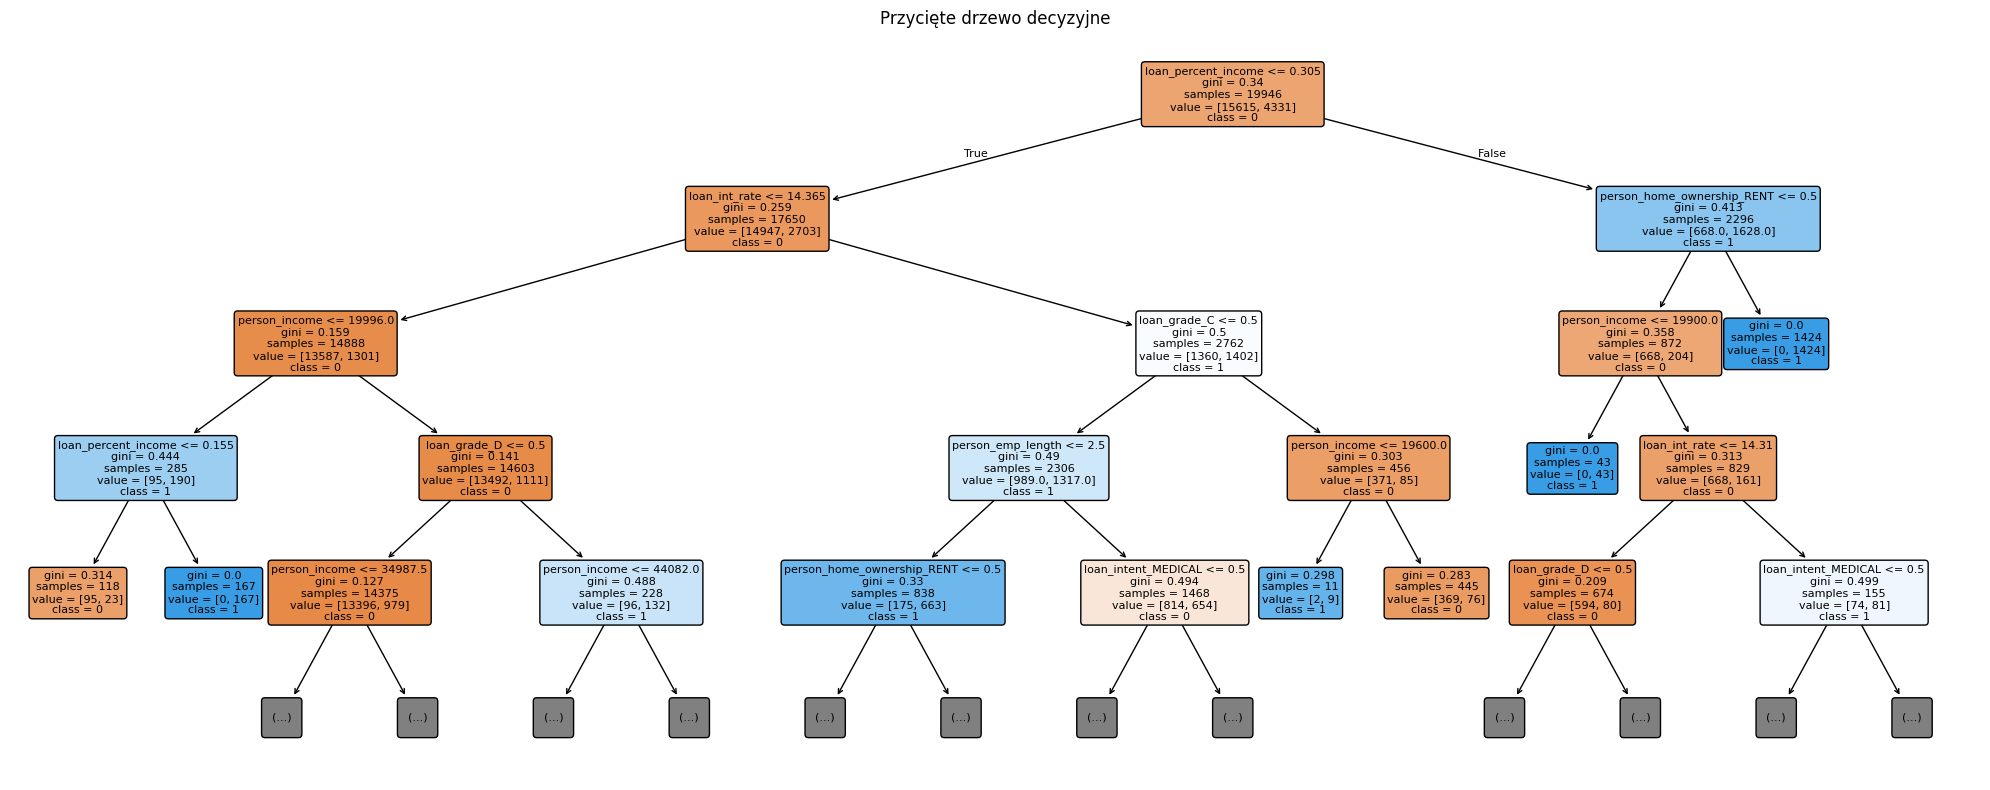

In [91]:
plt.figure(figsize=(20, 8))

plot_tree(
    decision_tree,
    feature_names=feature_names,
    class_names=label_encoder.classes_.astype(str),
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=4
)

plt.title("Przycięte drzewo decyzyjne")
plt.tight_layout()
plt.show()

In [92]:
tree_feature_importance = get_feature_importance(
    model=decision_tree,
    feature_names=feature_names,
    top_n=20
)

tree_feature_importance

,feature,importance
0,loan_percent_income,0.302568
1,loan_int_rate,0.199893
2,person_home_ownership_RENT,0.181126
3,person_income,0.086239
4,loan_intent_MEDICAL,0.034164
5,loan_intent_HOMEIMPROVEMENT,0.034058
6,person_emp_length,0.030778
7,loan_grade_D,0.029965
8,loan_grade_C,0.026442
9,loan_intent_PERSONAL,0.020431


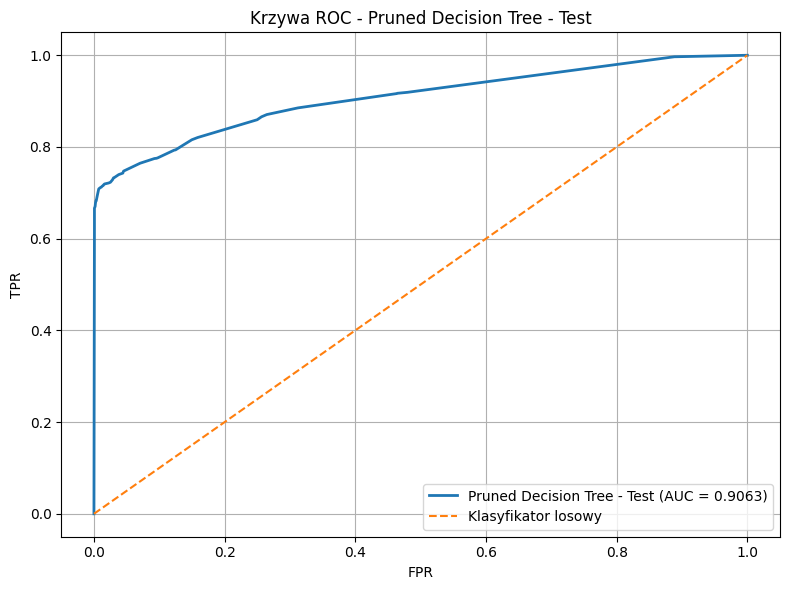

In [93]:
plot_roc(decision_tree_test_eval)

### RANDOM FOREST

In [94]:
def run_random_forest(
    X_train,
    y_train,
    n_estimators,
    random_state,
    max_depth=None,
    min_samples_leaf=1,
    min_samples_split=2,
    max_features="sqrt",
    n_jobs=-1,
    verbose=1
):
    if verbose:
        print("\n--- Random Forest Classification ---")

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        min_samples_split=min_samples_split,
        max_features=max_features,
        random_state=random_state,
        n_jobs=n_jobs,
        oob_score=True,
        verbose=verbose
    )

    model.fit(X_train, y_train)

    if verbose:
        print(f"OOB score: {model.oob_score_:.4f}")

    return model

In [95]:
random_forest = run_random_forest(
    X_train=X_train,
    y_train=y_train,
    n_estimators=1000,
    random_state=seed,
    n_jobs=n_jobs,
    verbose=verbose
)


--- Random Forest Classification ---


[Parallel(n_jobs=-4)]: Using backend ThreadingBackend with 19 concurrent workers.
[Parallel(n_jobs=-4)]: Done   3 tasks      | elapsed:    0.0s


building tree 12 of 1000
building tree 3 of 1000
building tree 6 of 1000
building tree 8 of 1000
building tree 10 of 1000
building tree 19 of 1000
building tree 2 of 1000
building tree 4 of 1000
building tree 7 of 1000
building tree 11 of 1000
building tree 14 of 1000
building tree 13 of 1000
building tree 17 of 1000
building tree 9 of 1000
building tree 1 of 1000
building tree 16 of 1000
building tree 5 of 1000
building tree 15 of 1000
building tree 18 of 1000
building tree 20 of 1000
building tree 21 of 1000
building tree 22 of 1000
building tree 23 of 1000
building tree 24 of 1000
building tree 25 of 1000
building tree 26 of 1000
building tree 27 of 1000
building tree 28 of 1000
building tree 29 of 1000
building tree 30 of 1000
building tree 31 of 1000
building tree 32 of 1000
building tree 33 of 1000
building tree 34 of 1000
building tree 35 of 1000
building tree 36 of 1000
building tree 37 of 1000
building tree 38 of 1000
building tree 39 of 1000
building tree 40 of 1000
building 

[Parallel(n_jobs=-4)]: Done 124 tasks      | elapsed:    0.4s


building tree 145 of 1000
building tree 146 of 1000
building tree 147 of 1000
building tree 148 of 1000
building tree 149 of 1000
building tree 150 of 1000
building tree 151 of 1000
building tree 152 of 1000
building tree 153 of 1000
building tree 154 of 1000
building tree 155 of 1000
building tree 156 of 1000
building tree 157 of 1000
building tree 158 of 1000
building tree 159 of 1000
building tree 160 of 1000
building tree 161 of 1000
building tree 162 of 1000
building tree 163 of 1000
building tree 164 of 1000
building tree 165 of 1000
building tree 166 of 1000
building tree 167 of 1000
building tree 168 of 1000
building tree 169 of 1000
building tree 170 of 1000
building tree 171 of 1000
building tree 172 of 1000
building tree 173 of 1000
building tree 174 of 1000
building tree 175 of 1000
building tree 176 of 1000
building tree 177 of 1000
building tree 178 of 1000
building tree 179 of 1000
building tree 180 of 1000
building tree 181 of 1000
building tree 182 of 1000
building tre

[Parallel(n_jobs=-4)]: Done 327 tasks      | elapsed:    1.1s


building tree 386 of 1000
building tree 387 of 1000
building tree 388 of 1000
building tree 389 of 1000
building tree 390 of 1000
building tree 391 of 1000
building tree 392 of 1000
building tree 393 of 1000
building tree 394 of 1000
building tree 395 of 1000
building tree 396 of 1000
building tree 397 of 1000
building tree 398 of 1000
building tree 399 of 1000
building tree 400 of 1000
building tree 401 of 1000
building tree 402 of 1000
building tree 403 of 1000
building tree 404 of 1000
building tree 405 of 1000
building tree 406 of 1000
building tree 407 of 1000
building tree 408 of 1000
building tree 409 of 1000
building tree 410 of 1000
building tree 411 of 1000
building tree 412 of 1000
building tree 413 of 1000
building tree 414 of 1000
building tree 415 of 1000
building tree 416 of 1000
building tree 417 of 1000
building tree 418 of 1000
building tree 419 of 1000
building tree 420 of 1000
building tree 421 of 1000
building tree 422 of 1000
building tree 423 of 1000
building tre

[Parallel(n_jobs=-4)]: Done 610 tasks      | elapsed:    2.2s


building tree 661 of 1000
building tree 662 of 1000
building tree 663 of 1000
building tree 664 of 1000
building tree 665 of 1000
building tree 666 of 1000
building tree 667 of 1000
building tree 668 of 1000
building tree 669 of 1000
building tree 670 of 1000
building tree 671 of 1000
building tree 672 of 1000
building tree 673 of 1000
building tree 674 of 1000
building tree 675 of 1000
building tree 676 of 1000
building tree 677 of 1000
building tree 678 of 1000
building tree 679 of 1000
building tree 680 of 1000
building tree 681 of 1000
building tree 682 of 1000
building tree 683 of 1000
building tree 684 of 1000
building tree 685 of 1000
building tree 686 of 1000
building tree 687 of 1000
building tree 688 of 1000
building tree 689 of 1000
building tree 690 of 1000
building tree 691 of 1000
building tree 692 of 1000
building tree 693 of 1000
building tree 694 of 1000
building tree 695 of 1000
building tree 696 of 1000
building tree 697 of 1000
building tree 698 of 1000
building tre

[Parallel(n_jobs=-4)]: Done 1000 out of 1000 | elapsed:    3.7s finished


OOB score: 0.9310


In [97]:
random_forest_train_eval = evaluate_model(
    model=random_forest,
    X=X_train,
    y_true=y_train,
    label_encoder=label_encoder,
    selected_percent=0.1,
    model_name="Random Forest - Train",
    verbose=verbose
)

[Parallel(n_jobs=19)]: Using backend ThreadingBackend with 19 concurrent workers.
[Parallel(n_jobs=19)]: Done   3 tasks      | elapsed:    0.0s
[Parallel(n_jobs=19)]: Done 124 tasks      | elapsed:    0.0s
[Parallel(n_jobs=19)]: Done 327 tasks      | elapsed:    0.1s
[Parallel(n_jobs=19)]: Done 610 tasks      | elapsed:    0.2s
[Parallel(n_jobs=19)]: Done 1000 out of 1000 | elapsed:    0.3s finished
[Parallel(n_jobs=19)]: Using backend ThreadingBackend with 19 concurrent workers.
[Parallel(n_jobs=19)]: Done   3 tasks      | elapsed:    0.0s
[Parallel(n_jobs=19)]: Done 124 tasks      | elapsed:    0.0s
[Parallel(n_jobs=19)]: Done 327 tasks      | elapsed:    0.1s
[Parallel(n_jobs=19)]: Done 610 tasks      | elapsed:    0.2s
[Parallel(n_jobs=19)]: Done 1000 out of 1000 | elapsed:    0.4s finished
[Parallel(n_jobs=19)]: Using backend ThreadingBackend with 19 concurrent workers.
[Parallel(n_jobs=19)]: Done   3 tasks      | elapsed:    0.0s
[Parallel(n_jobs=19)]: Done 124 tasks      | elaps


--- Random Forest - Train evaluation ---

Confusion matrix:
           Predicted: 1  Predicted: 0
Actual: 1          4331             0
Actual: 0             0         15615

Metrics:
Accuracy            : 1.0000
MER                 : 0.0000
Recall (TPR)        : 1.0000
Specificity (TNR)   : 1.0000
Precision (PPV)     : 1.0000
NPV                 : 1.0000
FPR                 : 0.0000
FDR                 : 0.0000
FNR                 : 0.0000
F1 score            : 1.0000
Youden Index        : 1.0000
Geometric mean      : 1.0000
Lift                : 4.6063
Gain                : 0.4606
AUC                 : 1.0000
TP                  : 4331
FP                  : 0
TN                  : 15615
FN                  : 0


In [222]:
random_forest_test_eval = evaluate_model(
    model=random_forest,
    X=X_test,
    y_true=y_test,
    label_encoder=label_encoder,
    selected_percent=0.1,
    model_name="Random Forest - Test",
    verbose=verbose
)

[Parallel(n_jobs=19)]: Using backend ThreadingBackend with 19 concurrent workers.
[Parallel(n_jobs=19)]: Done   3 tasks      | elapsed:    0.0s
[Parallel(n_jobs=19)]: Done 124 tasks      | elapsed:    0.0s
[Parallel(n_jobs=19)]: Done 327 tasks      | elapsed:    0.0s
[Parallel(n_jobs=19)]: Done 610 tasks      | elapsed:    0.1s
[Parallel(n_jobs=19)]: Done 1000 out of 1000 | elapsed:    0.3s finished
[Parallel(n_jobs=19)]: Using backend ThreadingBackend with 19 concurrent workers.
[Parallel(n_jobs=19)]: Done   3 tasks      | elapsed:    0.0s
[Parallel(n_jobs=19)]: Done 124 tasks      | elapsed:    0.0s
[Parallel(n_jobs=19)]: Done 327 tasks      | elapsed:    0.0s
[Parallel(n_jobs=19)]: Done 610 tasks      | elapsed:    0.1s
[Parallel(n_jobs=19)]: Done 1000 out of 1000 | elapsed:    0.2s finished



--- Random Forest - Test evaluation ---

Confusion matrix:
           Predicted: 1  Predicted: 0
Actual: 1          1358           498
Actual: 0            66          6627

Metrics:
Accuracy            : 0.9340
MER                 : 0.0660
Recall (TPR)        : 0.7317
Specificity (TNR)   : 0.9901
Precision (PPV)     : 0.9537
NPV                 : 0.9301
FPR                 : 0.0099
FDR                 : 0.0463
FNR                 : 0.2683
F1 score            : 0.8280
Youden Index        : 0.7218
Geometric mean      : 0.8512
Lift                : 4.6013
Gain                : 0.4601
AUC                 : 0.9353
TP                  : 1358
FP                  : 66
TN                  : 6627
FN                  : 498


In [99]:
random_forest_importance = get_feature_importance(
    model=random_forest,
    feature_names=feature_names,
    top_n=20
)

random_forest_importance

,feature,importance
0,loan_percent_income,0.213942
1,person_income,0.141359
2,loan_int_rate,0.137242
3,loan_amnt,0.080340
4,person_home_ownership_RENT,0.074299
5,person_emp_length,0.061883
6,loan_grade_D,0.057003
7,person_age,0.048738
8,hist_years,0.038671
9,loan_intent_EDUCATION,0.016582


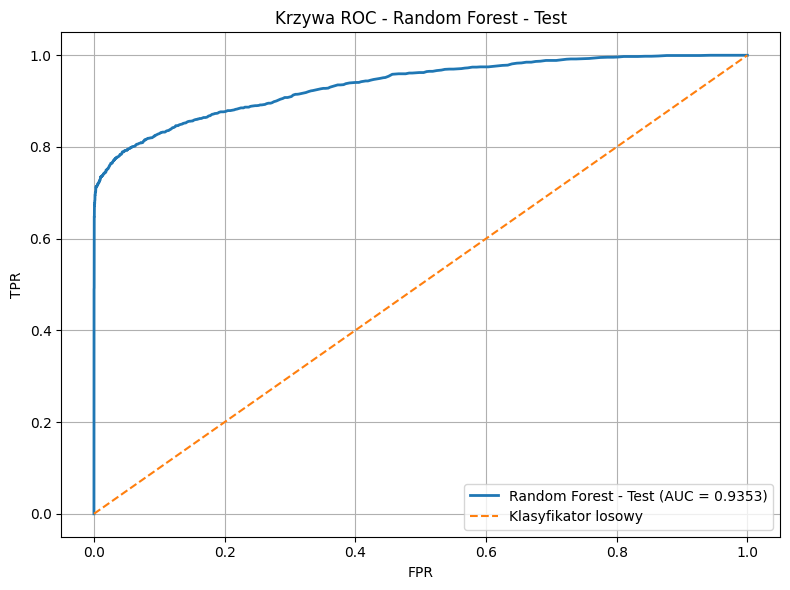

In [102]:
plot_roc(random_forest_test_eval)

### SVM

In [197]:
baseline_svm = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("svm", SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            class_weight="balanced",
            probability=True,
            random_state=seed
        ))
    ]
)

baseline_svm.fit(X_train, y_train)

c:\Users\janwz\anaconda3\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('svm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](22,)","['person_age','person_income','person_emp_length',...,'loan_grade_E', 'loan_grade_F','loan_grade_G']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,22
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [208]:
baseline_svm_train_eval = evaluate_model(
    model=baseline_svm,
    X=X_train,
    y_true=y_train,
    label_encoder=label_encoder,
    selected_percent=0.1,
    model_name="Baseline SVM RBF - Train",
    verbose=verbose
)

baseline_svm_test_eval = evaluate_model(
    model=baseline_svm,
    X=X_test,
    y_true=y_test,
    label_encoder=label_encoder,
    selected_percent=0.1,
    model_name="Baseline SVM RBF - Test",
    verbose=verbose
)


--- Baseline SVM RBF - Train evaluation ---

Confusion matrix:
           Predicted: 1  Predicted: 0
Actual: 1          3360           971
Actual: 0          1195         14420

Metrics:
Accuracy            : 0.8914
MER                 : 0.1086
Recall (TPR)        : 0.7758
Specificity (TNR)   : 0.9235
Precision (PPV)     : 0.7377
NPV                 : 0.9369
FPR                 : 0.0765
FDR                 : 0.2623
FNR                 : 0.2242
F1 score            : 0.7562
Youden Index        : 0.6993
Geometric mean      : 0.8464
Lift                : 4.5047
Gain                : 0.4505
AUC                 : 0.9231
TP                  : 3360
FP                  : 1195
TN                  : 14420
FN                  : 971

--- Baseline SVM RBF - Test evaluation ---

Confusion matrix:
           Predicted: 1  Predicted: 0
Actual: 1          1400           456
Actual: 0           540          6153

Metrics:
Accuracy            : 0.8835
MER                 : 0.1165
Recall (TPR)        : 0.

In [209]:
svm_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("svm", SVC(
            kernel="rbf",
            class_weight="balanced",
            probability=True,
            random_state=seed
        ))
    ]
)

svm_param_grid = {
    "svm__C": [0.5, 1, 2, 5, 10, 100],
    "svm__gamma": ["scale", 0.01, 0.05, 0.10]
}

svm_grid_search = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=n_jobs,
    verbose=verbose,
    return_train_score=True
)

svm_grid_search.fit(X_train, y_train)


print(f"Best SVM parameters: {svm_grid_search.best_params_}")
print(f"Best cross-validation AUC: {svm_grid_search.best_score_:.4f}")


Fitting 3 folds for each of 24 candidates, totalling 72 fits


c:\Users\janwz\anaconda3\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Best SVM parameters: {'svm__C': 100, 'svm__gamma': 0.01}
Best cross-validation AUC: 0.9084


In [210]:
svm_best = svm_grid_search.best_estimator_
best_svm_train_eval = evaluate_model(
    model=svm_best,
    X=X_train,
    y_true=y_train,
    label_encoder=label_encoder,
    selected_percent=0.1,
    model_name="Best SVM RBF - Train",
    verbose=verbose
)


--- Best SVM RBF - Train evaluation ---

Confusion matrix:
           Predicted: 1  Predicted: 0
Actual: 1          3388           943
Actual: 0          1032         14583

Metrics:
Accuracy            : 0.9010
MER                 : 0.0990
Recall (TPR)        : 0.7823
Specificity (TNR)   : 0.9339
Precision (PPV)     : 0.7665
NPV                 : 0.9393
FPR                 : 0.0661
FDR                 : 0.2335
FNR                 : 0.2177
F1 score            : 0.7743
Youden Index        : 0.7162
Geometric mean      : 0.8547
Lift                : 4.5394
Gain                : 0.4539
AUC                 : 0.9325
TP                  : 3388
FP                  : 1032
TN                  : 14583
FN                  : 943


In [211]:
best_svm_test_eval = evaluate_model(
    model=svm_best,
    X=X_test,
    y_true=y_test,
    label_encoder=label_encoder,
    selected_percent=0.1,
    model_name="Best SVM RBF - Test",
    verbose=verbose
)


--- Best SVM RBF - Test evaluation ---

Confusion matrix:
           Predicted: 1  Predicted: 0
Actual: 1          1404           452
Actual: 0           484          6209

Metrics:
Accuracy            : 0.8905
MER                 : 0.1095
Recall (TPR)        : 0.7565
Specificity (TNR)   : 0.9277
Precision (PPV)     : 0.7436
NPV                 : 0.9321
FPR                 : 0.0723
FDR                 : 0.2564
FNR                 : 0.2435
F1 score            : 0.7500
Youden Index        : 0.6842
Geometric mean      : 0.8377
Lift                : 4.4881
Gain                : 0.4488
AUC                 : 0.9160
TP                  : 1404
FP                  : 484
TN                  : 6209
FN                  : 452


In [212]:
svm_comparison = pd.DataFrame([
    {
        "Model": "Baseline SVM RBF",
        "Train Accuracy": baseline_svm_train_eval["metrics"]["Accuracy"],
        "Test Accuracy": baseline_svm_test_eval["metrics"]["Accuracy"],
        "Train AUC": baseline_svm_train_eval["metrics"]["AUC"],
        "Test AUC": baseline_svm_test_eval["metrics"]["AUC"],
        "Train Lift": baseline_svm_train_eval["metrics"]["Lift"],
        "Test Lift": baseline_svm_test_eval["metrics"]["Lift"],
        "Train Gain": baseline_svm_train_eval["metrics"]["Gain"],
        "Test Gain": baseline_svm_test_eval["metrics"]["Gain"],
        "Parameters": "C=1, gamma=scale, kernel=rbf"
    },
    {
        "Model": "Best SVM RBF",
        "Train Accuracy": best_svm_train_eval["metrics"]["Accuracy"],
        "Test Accuracy": best_svm_test_eval["metrics"]["Accuracy"],
        "Train AUC": best_svm_train_eval["metrics"]["AUC"],
        "Test AUC": best_svm_test_eval["metrics"]["AUC"],
        "Train Lift": best_svm_train_eval["metrics"]["Lift"],
        "Test Lift": best_svm_test_eval["metrics"]["Lift"],
        "Train Gain": best_svm_train_eval["metrics"]["Gain"],
        "Test Gain": best_svm_test_eval["metrics"]["Gain"],
        "Parameters": str(svm_grid_search.best_params_)
    }
])

svm_comparison.round(4)

,Model,Train Accuracy,Test Accuracy,Train AUC,Test AUC,Train Lift,Test Lift,Train Gain,Test Gain,Parameters
0,Baseline SVM RBF,0.8914,0.8835,0.9231,0.9117,4.5047,4.4612,0.4505,0.4461,"C=1, gamma=scale, kernel=rbf"
1,Best SVM RBF,0.9010,0.8905,0.9325,0.9160,4.5394,4.4881,0.4539,0.4488,"{'svm__C': 100, 'svm__gamma': 0.01}"


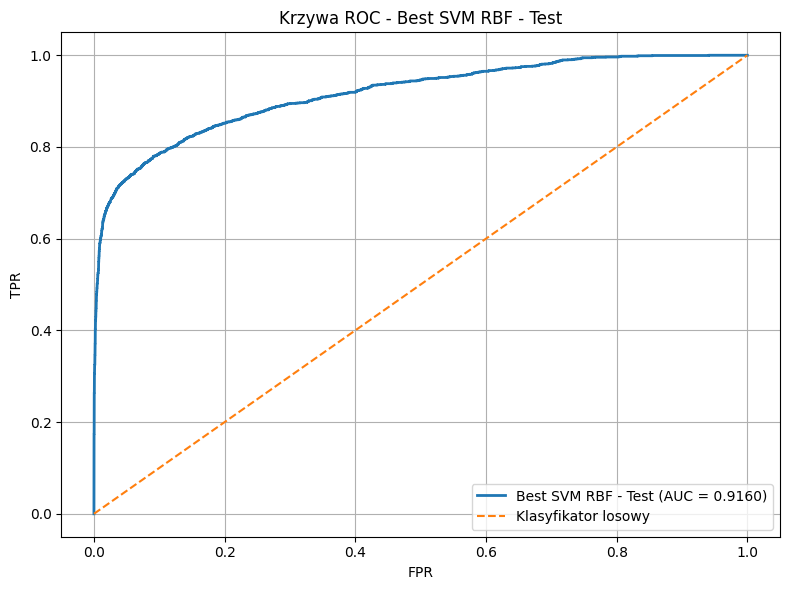

In [213]:
plot_roc(best_svm_test_eval)

### MODELS COMPARISON

In [214]:
model_comparison = compare_models([
    lr_best_test_eval,
    decision_tree_test_eval,
    random_forest_test_eval,
    best_svm_test_eval
])

model_comparison.round(4)

,Model,Accuracy,MER,Recall,Specificity,Precision,F1,AUC,Lift,Gain
0,Best LR - Test,0.8162,0.1838,0.7786,0.8267,0.5547,0.6478,0.8711,3.7446,0.3745
1,Pruned Decision Tree - Test,0.9282,0.0718,0.7144,0.9874,0.9404,0.8120,0.9063,4.5905,0.4591
2,Random Forest - Test,0.9340,0.0660,0.7317,0.9901,0.9537,0.8280,0.9353,4.6013,0.4601
3,Best SVM RBF - Test,0.8905,0.1095,0.7565,0.9277,0.7436,0.7500,0.9160,4.4881,0.4488


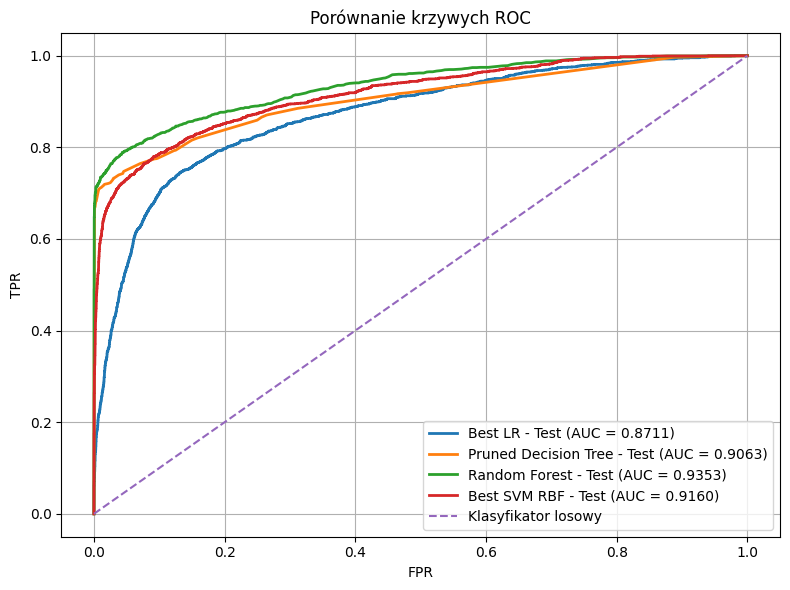

In [215]:
plot_roc_comparison([
    lr_best_test_eval,
    decision_tree_test_eval,
    random_forest_test_eval,
    best_svm_test_eval
])

### PROFIT OPTIMALIZATION

In [216]:
def calculate_portfolio_profit(model, model_name, cutoffs_grid = np.linspace(0.005, 0.95, 200)):
    pd_scores = model["y_proba"]
        
    df_biz = pd.DataFrame(index=X_test.index)
    df_biz['actual_default'] = y_test
    df_biz['PD'] = pd_scores
    df_biz['loan_int_rate'] = data_cleaned.loc[X_test.index, 'loan_int_rate'].astype(float)
    df_biz['loan_amnt'] = data_cleaned.loc[X_test.index, 'loan_amnt'].astype(float)
    
    home_ownership_series = data_cleaned.loc[X_test.index, 'person_home_ownership'].astype(str)
    lgd_map = {'MORTGAGE': 0.20, 'OWN': 0.35, 'RENT': 0.55, 'OTHER': 0.65}
    df_biz['LGD'] = home_ownership_series.map(lgd_map).fillna(0.45)
    
    interest_rates = df_biz['loan_int_rate'] / 100.0
    ead = df_biz['loan_amnt']
    
    best_profit = -np.inf
    best_cutoff = 0
    best_acceptance = 0
    profit_history = []
    
    table_cutoffs = [0.01, 0.02, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50, 0.60, 0.80]
    table_rows = []
    
    for cutoff in cutoffs_grid:
        accepted = df_biz['PD'] < cutoff
        revenue = (ead.loc[accepted & (df_biz['actual_default'] == 0)] * interest_rates.loc[accepted & (df_biz['actual_default'] == 0)]).sum()
        losses = (ead.loc[accepted & (df_biz['actual_default'] == 1)] * df_biz.loc[accepted & (df_biz['actual_default'] == 1), 'LGD']).sum()
        net_profit = revenue - losses
        profit_history.append(net_profit)
        
        if net_profit > best_profit:
            best_profit = net_profit
            best_cutoff = cutoff
            best_acceptance = accepted.mean() * 100
            
    for cutoff in table_cutoffs:
        accepted = df_biz['PD'] < cutoff
        revenue = (ead.loc[accepted & (df_biz['actual_default'] == 0)] * interest_rates.loc[accepted & (df_biz['actual_default'] == 0)]).sum()
        losses = (ead.loc[accepted & (df_biz['actual_default'] == 1)] * df_biz.loc[accepted & (df_biz['actual_default'] == 1), 'LGD']).sum()
        net_profit = revenue - losses
        table_rows.append({
            'Próg Odcięcia (Cutoff)': f"{cutoff*100:.1f}%",
            'Zysk Netto (USD)': net_profit,
            'Wskaźnik Akceptacji': f"{accepted.mean()*100:.2f}%"
        })
        
    table_rows.append({
        'Próg Odcięcia (Cutoff)': f"**{best_cutoff*100:.2f}% (OPTIMUM)**",
        'Zysk Netto (USD)': best_profit,
        'Wskaźnik Akceptacji': f"{best_acceptance:.2f}%"
    })
    
    df_model_table = pd.DataFrame(table_rows)
    print(f"\n--- Rozkład zysku dla: {model_name} ---")
    print(df_model_table.to_string(index=False, formatters={'Zysk Netto (USD)': '{:,.2f}'.format}))
    print("-" * 65)
            
    return {
        'Model': model_name,
        'Optymalny Cut-off (%)': round(best_cutoff * 100, 2),
        'Maksymalny Zysk (USD)': round(best_profit, 2),
        'Wskaźnik Akceptacji (%)': round(best_acceptance, 2),
        'cutoffs': cutoffs_grid * 100,
        'profits': profit_history
    }

In [226]:
profit_results = []

res_lr = calculate_portfolio_profit(lr_best_test_eval, 'Regresja Logistyczna GridSearch')
profit_results.append(res_lr)

print(f"Max zysk: {res_lr['Maksymalny Zysk (USD)']:,.2f} USD")


--- Rozkład zysku dla: Regresja Logistyczna GridSearch ---
Próg Odcięcia (Cutoff) Zysk Netto (USD) Wskaźnik Akceptacji
                  1.0%        48,980.79               0.75%
                  2.0%       143,078.08               2.16%
                  5.0%       488,707.56               6.99%
                 10.0%     1,228,256.26              18.36%
                 15.0%     1,836,762.86              28.68%
                 20.0%     2,331,493.48              37.93%
                 25.0%     2,766,368.71              45.17%
                 30.0%     3,064,549.79              51.39%
                 40.0%     3,554,724.45              62.14%
                 50.0%     3,662,621.10              69.53%
                 60.0%     3,647,858.42              74.96%
                 80.0%     1,988,942.21              85.45%
  **56.06% (OPTIMUM)**     3,713,655.55              72.85%
-----------------------------------------------------------------
Max zysk: 3,713,655.55 USD


In [228]:
res_dt = calculate_portfolio_profit(decision_tree_test_eval, 'Pruned Decision Tree')
profit_results.append(res_dt)

print(f"Max zysk: {res_dt['Maksymalny Zysk (USD)']:,.2f} USD")


--- Rozkład zysku dla: Pruned Decision Tree ---
Próg Odcięcia (Cutoff) Zysk Netto (USD) Wskaźnik Akceptacji
                  1.0%       618,267.08               8.62%
                  2.0%       618,267.08               8.62%
                  5.0%     2,378,679.83              42.47%
                 10.0%     4,189,713.90              69.76%
                 15.0%     4,636,541.04              75.48%
                 20.0%     4,800,719.23              80.97%
                 25.0%     4,819,127.13              81.86%
                 30.0%     4,832,701.52              82.57%
                 40.0%     4,867,375.72              83.28%
                 50.0%     4,872,986.62              83.51%
                 60.0%     4,881,600.49              83.90%
                 80.0%     4,829,003.51              84.44%
  **59.38% (OPTIMUM)**     4,881,600.49              83.90%
-----------------------------------------------------------------
Max zysk: 4,881,600.49 USD


In [229]:
res_rf = calculate_portfolio_profit(random_forest_test_eval, 'Random Forest')
profit_results.append(res_rf)

print(f"Max zysk: {res_rf['Maksymalny Zysk (USD)']:,.2f} USD")


--- Rozkład zysku dla: Random Forest ---
Próg Odcięcia (Cutoff) Zysk Netto (USD) Wskaźnik Akceptacji
                  1.0%       685,486.45              10.70%
                  2.0%     1,179,952.09              18.41%
                  5.0%     2,374,936.46              35.86%
                 10.0%     3,591,315.60              55.29%
                 15.0%     4,232,609.01              66.18%
                 20.0%     4,613,208.85              72.62%
                 25.0%     4,753,072.85              76.21%
                 30.0%     4,892,530.13              78.90%
                 40.0%     4,967,998.68              81.83%
                 50.0%     4,948,837.88              83.33%
                 60.0%     4,889,328.66              84.36%
                 80.0%     4,061,724.95              87.16%
  **38.96% (OPTIMUM)**     4,979,825.49              81.62%
-----------------------------------------------------------------
Max zysk: 4,979,825.49 USD


In [230]:
res_svm = calculate_portfolio_profit(best_svm_test_eval, 'SVM RBF GridSearch')
profit_results.append(res_svm)

print(f"Max zysk: {res_svm['Maksymalny Zysk (USD)']:,.2f} USD")


--- Rozkład zysku dla: SVM RBF GridSearch ---
Próg Odcięcia (Cutoff) Zysk Netto (USD) Wskaźnik Akceptacji
                  1.0%     1,053,984.95              12.28%
                  2.0%     1,283,352.01              14.94%
                  5.0%     2,252,721.04              29.59%
                 10.0%     4,170,126.55              63.76%
                 15.0%     4,461,109.46              70.56%
                 20.0%     4,573,078.19              74.20%
                 25.0%     4,631,497.78              76.55%
                 30.0%     4,656,985.16              78.52%
                 40.0%     4,637,910.98              81.05%
                 50.0%     4,532,114.46              82.99%
                 60.0%     4,203,529.60              84.76%
                 80.0%     2,846,918.97              88.90%
  **27.57% (OPTIMUM)**     4,663,820.15              77.44%
-----------------------------------------------------------------
Max zysk: 4,663,820.15 USD



================== PORÓWNANIE FINANSOWE MODELI ==================
                          Model  Optymalny Cut-off (%) Maksymalny Zysk (USD)  Wskaźnik Akceptacji (%)
                  Random Forest                  38.96          4,979,825.49                    81.62
           Pruned Decision Tree                  59.38          4,881,600.49                    83.90
             SVM RBF GridSearch                  27.57          4,663,820.15                    77.44
Regresja Logistyczna GridSearch                  56.06          3,713,655.55                    72.85


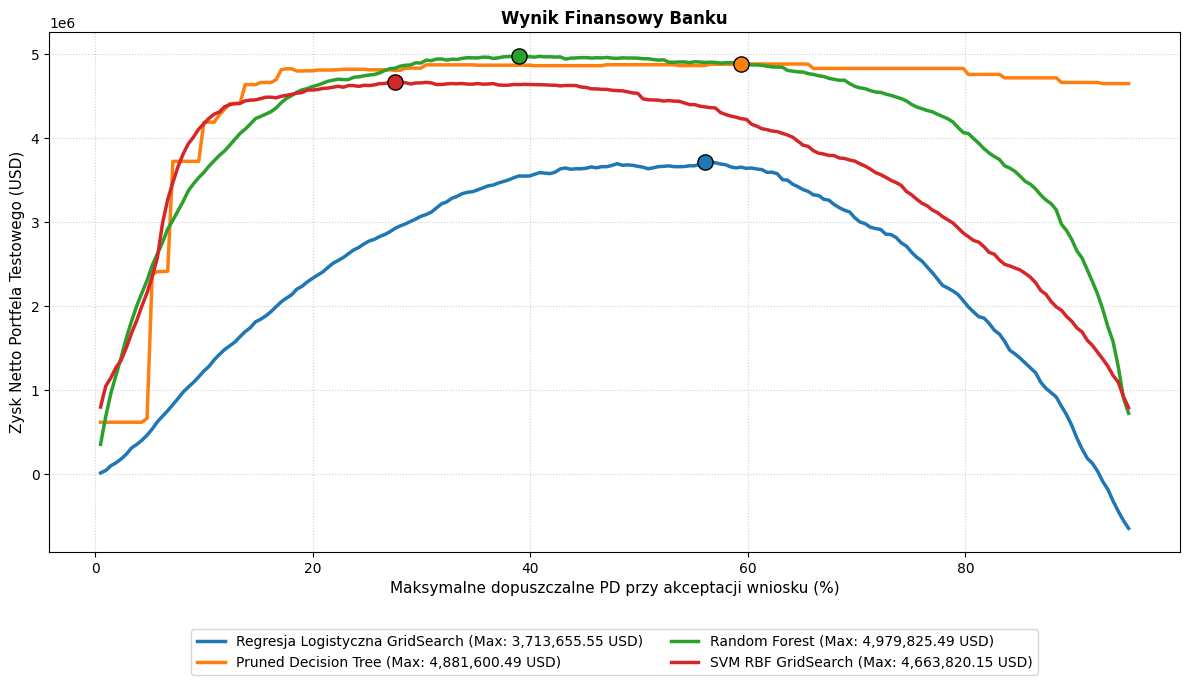

In [231]:
if profit_results:
    unique_results = {}
    for res in profit_results:
        unique_results[res['Model']] = res
    profit_results = list(unique_results.values())

    df_profit_summary = pd.DataFrame([{k: v for k, v in res.items() if k not in ['cutoffs', 'profits']} for res in profit_results])
    df_profit_summary = df_profit_summary.sort_values(by='Maksymalny Zysk (USD)', ascending=False)
    
    print("\n" + "="*65)
    print(" PORÓWNANIE FINANSOWE MODELI ".center(65, "="))
    print("="*65)
    print(df_profit_summary.to_string(index=False, formatters={'Maksymalny Zysk (USD)': '{:,.2f}'.format}))
    print("="*65)
    
    plt.figure(figsize=(12, 7))
    for res in profit_results:
        zysk_formatowany = f"{res['Maksymalny Zysk (USD)']:,.2f}"
        plt.plot(res['cutoffs'], res['profits'], label=f"{res['Model']} (Max: {zysk_formatowany} USD)", linewidth=2.5)
        plt.scatter(res['Optymalny Cut-off (%)'], res['Maksymalny Zysk (USD)'], s=120, zorder=5, edgecolors='black')
        
    plt.title('Wynik Finansowy Banku', fontsize=12, fontweight='bold')
    plt.xlabel('Maksymalne dopuszczalne PD przy akceptacji wniosku (%)', fontsize=11)
    plt.ylabel('Zysk Netto Portfela Testowego (USD)', fontsize=11)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=2, fontsize=10)
    plt.tight_layout()
    plt.show()
    